# Harvesting VRP — v2: ranking 14 indices with Qbit-shaped data

**A runnable adaptation with an explicit synthetic/real data boundary.** Each day the same model ranks a **short 25-delta M1 put, held for
up to 10 business days, exiting earlier at its fixed expiry**, on each of 14
indices, plus **SKIP**. For new entries, switch to the next monthly maturity
when the front expiry has `nTrdDays < 5`; exactly five days does not switch.
An existing cohort keeps its original expiry and strike. It can open one new
cohort per day; earlier cohorts continue to their own exits.

**Timing contract: observe through EOD t−1, execute at EOD t.** Every model
input, including Greeks, premium, IV, DTE, calendar fields and interaction
products, uses the preceding observation. Day-t marks determine execution
and subsequent P&L; they never enter that day's feature vector.

Read alongside [Qbit features](../../docs/qbit/features.md),
[Qbit UPNL](../../docs/qbit/upnl.md), the
[paper](../../docs/research/papers/Harvesting_the_Volatility_Risk_Premium_A_Learning_to_Rank_Approach.md),
and [v1](harvesting_vrp_synthetic.ipynb), which remains unchanged.

| Retained from the paper / v1 | Qbit adaptation |
|---|---|
| Daily ranking with a learned SKIP candidate | 14 indices, one common structure; ticker is a join key, not an input |
| Premium-normalized strategy history, Sharpe, drawdowns and ranks | Completed cohorts in trailing trading-day windows; USD source-trade cash flows |
| Gross path score; training-only quantiles 10/40/60/90% | Daily marked P&L, rather than minute 0DTE marks; exclude labels not yet completed |
| S1–S5 thresholds, correlation screen, stability and group caps | Index features are candidate-specific (PS); calendar and prior-session VIX/VVIX are common (CS) |
| LambdaRank, gains `[0,1,3,7,15]`, NDCG@1/@3, truncation 5 | 15 rows per synthetic date; group sizes are computed, never hard-coded in LightGBM |
| 50 TPE trials per annual fit; 2000 rounds; patience 50 | Same 2021–2025 prediction years and chronological fitting/tuning/gate windows |
| Gate maximizes held-out Sortino | All observed gaps plus zero, as you requested; overlapping cash flows booked on mark dates |
| Third optimization targets 16% training volatility | **User-approved:** one allocation in Qbit risk units replaces seven SPX margin/contract rules |

This is **unhedged**, matching v1: short-structure P&L is `-pnlOpt`, not
`-(pnlOpt-pnlOptDel)`. Subtract the supplied entry `cost` once. Funding, cash
interest and unprovided closing costs are excluded and explicitly reported.
These assumptions describe the research return series, not a complete execution model.

The saved example runs in synthetic mode and has no real market history or real performance. Synthetic `idxRef`
uses familiar index labels only for readability; load your actual 14 IDs,
currencies, coverage and calendars for real work. The fake markets share one
synchronous business-day clock. Real daily dates alone cannot prove that Asian,
European and US observations were simultaneously available.

No blanket cross-ranking, standardization, asinh or winsorization is applied.
Selected numeric values, explicitly named rank columns and products enter
LightGBM. Undefined values remain missing. No latent generator state, ticker,
future P&L, terminal Greeks or exit-date knowledge becomes a model feature.

### Where you replace the data

1. In **A — Choose the source**, set `DATA_SOURCE = "real"`.
2. Edit **only `load_real_inputs()` in B**: select your integer IDs and connect
   the clearly marked FX, VIX/VVIX and calendar/availability readers. The Qbit
   reference, UPNL and feature-family reads are already shown there.
3. Restart the kernel and **Run All**. C only defines a synthetic producer;
   real mode never calls it. D validates the returned tables and shows samples.
4. **Everything after D consumes those tables.** No fake spot, IV or P&L is
   generated below that line. Labels, derived features and all three
   optimizations remain shared.

`A → B or C → D: input tables → labels/features → selection → model → gate → sizing`

The real loader is a visible integration template, not an already-connected
private data service. Its unfilled readers stop with a message listing what
you must supply; it never substitutes synthetic data.

In [1]:
import os
import sys
import time
from pathlib import Path
from collections import Counter
from importlib.metadata import version

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'docs/qbit/features.md').exists())
cache = ROOT / 'tmp/harvesting_v2_cache'
cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(cache / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(cache))

import numpy as np
import pandas as pd
import scipy.stats as st
from scipy.special import ndtr, ndtri
from scipy.optimize import brentq
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import pandas_market_calendars as mcal
from IPython.display import display

started = time.perf_counter()
SEED = 260824786  # Reuse v1's explicitly synthetic seed.
ANN, NAV0, TARGET_VOL = 252, 5_000_000.0, .16  # Paper settings.
HOLD = 10  # User's holding-period choice.
M1_ROLL_DAYS = 5  # User: roll new entries only when front nTrdDays < 5.
VARIANT = 'put_M1_d25_h10'
STRUCTURE_WEIGHT = -1.0
GAIN = np.array([0, 1, 3, 7, 15])
GRADE_QUANTILES = [.10, .40, .60, .90]
PAPER_TRIALS, PAPER_ROUNDS, PAPER_PATIENCE = 50, 2000, 50
PREDICTION_YEARS = range(2021, 2026)
optuna.logging.set_verbosity(optuna.logging.WARNING)
display(pd.Series({p: version(p) for p in
    ['numpy', 'pandas', 'scipy', 'lightgbm', 'optuna', 'matplotlib']}, name='version'))
print('Kernel selected through DEV:', sys.executable)

PATH_KEY = ['ticker', 'trdDate', 'expiryDate']
INTERVAL_KEY = PATH_KEY + ['edate']
FEATURE_NAMES = {
    'logret': [f'logret_{w}' for w in [1, 2, 3, 5, 10, 21, 63, 252, 504]],
    'vol_ctc': [f'vol_ctc_{w}' for w in [5, 10, 21, 63, 126, 252]],
    'vol_irv': [f'vol_irv_{w}' for w in [1, 5, 10, 21, 63, 126, 252]],
    'volsurf': ['iv_1m_50d', 'iv_1m_25d', 'iv_1m_75d', 'iv_slope1m3m'],
    'beta1': [f'{name}_{w}' for w in [21, 63, 126, 252]
              for name in ['beta1', 'beta1_r2', 'beta1_rvol']],
    'skew': [f'skew_{w}' for w in [21, 63, 126, 252]],
    'range0': [f'rg_{w}' for w in [5, 10, 21, 63, 126, 252]],
    'mom_aligned': [f'mom_aligned_{w}_1' for w in [10, 21, 63, 126, 252]],
}

numpy          2.4.2
pandas         2.3.3
scipy         1.17.1
lightgbm       4.7.0
optuna         4.5.0
matplotlib    3.10.8
Name: version, dtype: object

Kernel selected through DEV: /Users/constantinpavlicu/dev/apollo3/venv/bin/python


## A — Choose the source

The saved outputs use `synthetic`. Change the string below to `real` only after
connecting B. Restarting clears any data left by an earlier run.

In [2]:
DATA_SOURCE = "synthetic"  # Choose "synthetic" or "real".

## B — Real data: edit this loader only

This function returns a plain dictionary of DataFrames. **Replace the six
`None` assignments**, using your own readers or already-prepared exports.
Do not edit label/feature/model cells to insert data.

| Returned name | Required content | Where it comes from |
|---|---|---|
| `idx_ref` | `secId` (integer), `ticker`, `ccy`; your 14 indices | `idxRef` |
| `daily_raw` | One **long-source, unit-rtvega** row per path/mark; columns listed below | Raw `/date`, selected put variant |
| `terminal_raw` | `ticker,trdDate,expiryDate,edate,exitDate,pnlOpt` for completed paths | Raw `/trd`; reconciliation only |
| `feature_tables` | Dict keyed by the eight `FEATURE_NAMES` families; each table: `date,secId,ticker,feature,value` | Persisted Qbit families; legacy `vol_irv` may omit `secId` |
| `fx_long` | `edate,ccy,fx_price` (USD per native currency) | Your exact-date FX reader |
| `vix_5m` | `timestamp,symbol,price`; timestamp is timezone-aware UTC, symbols VIX/VVIX | Your five-minute price reader |
| `us_schedule` | US session-date index; timezone-aware `market_open,market_close` | Calendar matching that price feed |
| `calendar` | `date,decision_at`; see below | Your declared daily research clock |
| `feature_clock` | `date,ticker,observation_date,available_at,quote_available_at` | Availability of prior observations and their closing Greeks |

Required daily fields are:
`ticker,trdDate,expiryDate,sdate,edate,exitDate,variant,nTrdDays,qty,rtvega,`
`pnlOpt,cost,spot,delta,gamma,theta,vega,premium,ivol,contractSize`.
Keep source units. The shared code applies the short sign and converts FX once.
It does not multiply P&L by source `qty`, regenerate Greeks or undo rtvega
normalization. IV is decimal, theta annual, and vega per unit decimal IV here;
adapt differing source conventions inside this loader.

For this single-leg put, the model recovers each unit-option Greek as
`saved_greek / (qty * contractSize)` for delta, gamma, theta and vega,
then applies the short-position sign. Only delta is dimensionless; the
others retain their native per-option units. The configured Qbit loader can obtain the
historical `contractSize` from paired `trdPrc` metadata; the code below joins
only that metadata onto raw UPNL. It never substitutes loader-scaled P&L.
Use the actual historical multiplier, not an assumed constant of 100. A missing
multiplier is an input error. If your exported Greeks are already per-option,
adapt them to the documented quantity-weighted source contract in this loader.

`calendar.date` is the full ordered daily ledger/history clock from 2013 through
the final post-2025 settlement, including zero-P&L days. `decision_at` is the
timezone-aware **EOD t execution/decision timestamp** for each ranking query;
use `NaT` on settlement-only dates after the entry period. The shared boundary
derives `feature_cutoff_at` from the preceding calendar row's `decision_at`.
Thus data published on t are excluded even if dated t−1. Keep 2021–2025 as
prediction years. Do not create the calendar by dropping missing-price dates.

`feature_clock` has one row per opening `(date,ticker)`. Its `observation_date`
is the scheduled preceding observation date for that index, accounting for
its market holidays. `available_at` covers persisted features and completed
trade marks; `quote_available_at` covers the closing Greeks/quote **on that
observation date**. Both must be at or before `feature_cutoff_at`, not merely
before today's execution. A missing quote on the scheduled observation date
leaves missing features; do not silently choose an older date. The initial
warm-up row may have no preceding observation or availability.

Position features describe the previous observation's candidate for that
index/structure. EOD t executes the variant's day-t option. At a maturity switch
these can be different contracts; never replace lagged descriptors with day-t
Greeks to make them match the execution contract. Supply publication times and
market calendars from the actual source conventions.

The raw UPNL variant must already implement your **fixed expiry**, **roll new
entries when front `nTrdDays < 5`**, and **exit at min(10 business days, expiry)**
rules. A different contract path cannot be repaired by changing its dates here.
Use the actual put variant name in `VARIANT`; do not rename a call's P&L.

The loader uses the raw `util.load` route documented in the guides, so it does
not accidentally consume an already-weighted or `qty_one` panel. If your own
reader attaches `secId`/`ccy`, the boundary validates them before merging.

In [3]:
def load_real_inputs():
    """EDIT HERE: adapt actual Qbit sources to the shared table contract."""
    # Replace these with your IDs/readers. These are deliberate, visible gaps.
    selected_sec_ids = None  # Your 14 actual integer IDs; not synthetic 1..14.
    fx_long = None           # DataFrame: edate, ccy, fx_price.
    vix_5m = None            # DataFrame: timestamp, symbol, price.
    us_schedule = None      # Session-date index; market_open, market_close.
    calendar = None         # DataFrame: date, decision_at = EOD execution time (aware zone).
    feature_clock = None    # DataFrame: date, ticker, observation_date,
                            #            available_at, quote_available_at for the prior observation.
    supplied = dict(selected_sec_ids=selected_sec_ids, fx_long=fx_long, vix_5m=vix_5m,
                    us_schedule=us_schedule, calendar=calendar, feature_clock=feature_clock)
    missing = [name for name, value in supplied.items() if value is None]
    if missing:
        raise ValueError('Edit load_real_inputs() in B; supply: '+', '.join(missing))

    # These paths/readers are documented Qbit APIs. Use a Qbit-enabled kernel
    # or replace these reads with your prepared exports in this same function.
    import qbit.util as util

    idx_ref = util.load(util.path('idxRef')).pd()
    idx_ref = idx_ref.loc[idx_ref.secId.isin(selected_sec_ids), ['secId', 'ticker', 'ccy']].copy()
    if set(idx_ref.secId) != set(selected_sec_ids):
        raise ValueError('selected_sec_ids are not all present in idxRef')
    tickers = idx_ref.ticker.tolist()
    sections = {}
    for section in ['date', 'trd']:
        sections[section] = pd.concat([
            util.load(util.path('VAD', 'upnl_vola', section, VARIANT, ticker)).pd()
            for ticker in tickers], ignore_index=True)
    feature_tables = {}
    for family, names in FEATURE_NAMES.items():
        table = util.load(util.path('features', family)).pd()
        feature_tables[family] = table.loc[table.ticker.isin(tickers) & table.feature.isin(names)].copy()

    # Only contract metadata comes from the configured, documented Qbit loader.
    # P&L and weighted Greeks above remain the raw util.load values.
    from qbit.bckt.loader import load_upnl
    metadata_cfg = dict(upnl_label='VAD/upnl_vola', structure={VARIANT: 1.0},
                        upnl_scale_mode='unit_rtvvega', risk_unit='notional')
    enriched = load_upnl(metadata_cfg, section='date')
    contract_metadata = enriched.loc[enriched.ticker.isin(tickers),
                                      INTERVAL_KEY+['contractSize']]
    sections['date'] = sections['date'].drop(columns='contractSize', errors='ignore').merge(
        contract_metadata, on=INTERVAL_KEY, how='left', validate='one_to_one')

    # The declared decision clock defines the entry universe, not /trd availability.
    entry_days = calendar.loc[calendar.decision_at.notna(), 'date']
    daily_raw = sections['date'].loc[sections['date'].trdDate.isin(entry_days)].copy()
    terminal_raw = sections['trd'].loc[sections['trd'].trdDate.isin(entry_days)].copy()
    return dict(idx_ref=idx_ref, daily_raw=daily_raw, terminal_raw=terminal_raw,
                feature_tables=feature_tables, fx_long=fx_long, vix_5m=vix_5m,
                us_schedule=us_schedule, calendar=calendar, feature_clock=feature_clock)

## C — Synthetic producer: real mode skips this function

The following cell **defines** `make_synthetic_inputs()`. It only runs when D
selects synthetic mode. All mock spot/IV paths, Black–Scholes marks, source
normalization, fixed-expiry examples and fake feature observations are local to
this function. Only the returned tables cross the boundary.

The generator assumptions and normalized-unit conventions remain visible below.
### Synthetic observations — Fabricate the observations underlying the Qbit tables

The fake spot processes have a shared market shock, index-specific shocks and
persistent volatility. IV has a time-varying premium over latent volatility.
Those are **generator assumptions**, never model inputs. FX is USD per unit of
native currency; one series is shared by indices using the same currency.

Use a synthetic weekday calendar starting in **2013**, matching your stated
daily-history coverage. Synthetic `secId` values are integer placeholders 1–14;
load actual integer IDs from `idxRef` for real data. Pandas nullable `Int64`
preserves integer IDs when SKIP has no security ID.
Rolling features keep their natural warm-up gaps;
there is no invented pre-2013 history. Extend marks after December 2025
to settle the final entries. That settlement tail is shown separately and does
not enter any annual fit. **M1 refers to a fixed monthly expiry**, shared by
successive daily entries until the user's five-business-day roll rule changes
the expiry selected for new trades. The synthetic calendar uses third Fridays
for all indices purely as a mock expiry schedule, not a claim about their actual
exchange calendars. The current expiry is still the front on its expiry date;
its zero `nTrdDays` triggers the roll for new entries. Existing positions are
not rolled and can settle that day.

Here `nTrdDays` counts business-day steps from the observation date to expiry.
Real data must use its saved `expiryDate` and `nTrdDays` with each index's actual
calendar. The synthetic exit is `min(entry + 10 business days, selected expiry)`.

We generate source fields with Black–Scholes at zero funding/dividend rates.
The units are decimal annualized IV, annual theta and vega per unit decimal IV.
Synthetic spread cost is 1% of the opening premium. None of these generator
parameters is a fitted threshold or a proposed real-market execution assumption.

### Synthetic UPNL — Qbit-shaped `/date` and `/trd`: keep entry identity

Use the user's maturity adjustment: **`urtvega = unit_vega / sqrt(T)`**,
where `T = btime` is remaining time to option expiry in years, not the ten-day
holding period. Here `btime = nTrdDays / 252`, as in the synthetic pricer.
Vega is per unit decimal IV; a per-volatility-point convention would differ
by a factor of 100. The time unit must also match when comparing risk quantities.

For zero dividends, Black–Scholes gives
$\mathrm{vega}=S\phi(d_1)\sqrt{T}$, hence
$\mathrm{vega}/\sqrt{T}=S\phi(d_1)$.
This removes the explicit square-root-of-time factor. At matched delta and
spot it equalizes this exposure across maturities; at fixed strike, $d_1$ also
changes with maturity, so it does not remove every maturity effect or make all
Greeks equal. [IBKR's custom adjusted vega](https://investors.interactivebrokers.com/en/index.php?f=29520)
uses the same inverse-square-root idea, with calendar days as its stated time unit.

For the fake unit contract multiplier, opening `qty = 1 / abs(urtvega_open)`.
Keep that source quantity fixed along the path and compute each mark's
`rtvega = quantity_weighted_vega / sqrt(remaining_btime)`.
Opening `rtvega` is one; subsequent values can change with spot and moneyness.
At expiry the source premium is intrinsic value. The synthetic settled contract
has zero remaining Greeks, including `rtvega`; never evaluate `vega / sqrt(0)`.
The source remains long; the short sign is applied **once downstream**.
`sourceQty` is not the strategy allocation.

This corrects the earlier synthetic `vega × IV` normalization: that quantity
measures sensitivity to a proportional IV change, rather than this maturity
adjustment. The Qbit guide calls the field "relative vega" but does not give
the private producer's exact `urtvega` formula. This notebook adopts your
interpretation explicitly; verify Qbit's time basis, reference-tenor factors
and vega scaling in its implementation before comparing numerical risk units.
For real data consume saved `qty` and `rtvega` instead of reconstructing them.

The opening row has zero interval P&L and the entry cost. Subsequent rows carry
the original `trdDate`, the actual interval `(sdate, edate)`, and mark Greeks.
For features, use the prior observation's opening row. `/trd` contains complete paths;
it is useful to reconcile totals, but must not define which candidates existed
at an earlier decision date.

Only the fields used here are simulated. The toy explicitly uses `contractSize=1`.
Other paired contract metadata, broker margin and higher Greeks are omitted.

In [4]:
def make_synthetic_inputs():
    """Make only the input tables; no synthetic state escapes this function."""
    rng = np.random.default_rng(SEED)

    idx_ref = pd.DataFrame({
        'ticker': ['SPX', 'NDX', 'RUT', 'SX5E', 'DAX', 'CAC', 'FTSE',
                   'SMI', 'NKY', 'HSI', 'AS51', 'KOSPI', 'TSX', 'IBEX'],
        'ccy': ['USD', 'USD', 'USD', 'EUR', 'EUR', 'EUR', 'GBP',
                'CHF', 'JPY', 'HKD', 'AUD', 'KRW', 'CAD', 'EUR'],
    })
    idx_ref['secId'] = pd.Series(range(1, len(idx_ref)+1), dtype='Int64')
    TICKERS = idx_ref.ticker.tolist()
    CANDIDATES = sorted(TICKERS + ['SKIP'])
    entry_dates = pd.bdate_range('2013-01-01', '2025-12-31')
    # Include the next two monthly dates beyond the last entry month so both the
    # front expiry and its successor exist when evaluating the user's roll rule.
    expiry_months = pd.period_range(entry_dates[0].to_period('M'),
                                   entry_dates[-1].to_period('M')+2, freq='M')
    monthly_expiries = pd.DatetimeIndex([
        month.start_time + pd.offsets.WeekOfMonth(week=2, weekday=4)
        for month in expiry_months])
    front_index = monthly_expiries.searchsorted(entry_dates, side='left')
    front_expiry = monthly_expiries[front_index]
    front_days = np.busday_count(entry_dates.to_numpy(dtype='datetime64[D]'),
                                 front_expiry.to_numpy(dtype='datetime64[D]'))
    roll_next = front_days < M1_ROLL_DAYS
    entry_expiry = monthly_expiries[front_index + roll_next.astype(int)]
    entry_days = np.busday_count(entry_dates.to_numpy(dtype='datetime64[D]'),
                                 entry_expiry.to_numpy(dtype='datetime64[D]'))
    holding_days = np.minimum(HOLD, entry_days)
    entry_schedule = pd.DataFrame({
        'frontExpiryDate': front_expiry, 'front_nTrdDays': front_days,
        'rolled_next': roll_next, 'expiryDate': entry_expiry, 'nTrdDays': entry_days,
        'exitDate': [date+pd.offsets.BDay(int(days)) for date, days in zip(entry_dates, holding_days)],
    }, index=entry_dates.rename('trdDate'))
    dates = pd.bdate_range(entry_dates[0], entry_dates[-1] + pd.offsets.BDay(HOLD))
    n_days, n_indices = len(dates), len(TICKERS)
    common = rng.normal(size=n_days)
    log_vol = np.empty((n_days, n_indices))
    centers = np.log(rng.uniform(.13, .28, n_indices))
    log_vol[0] = centers
    for t in range(1, n_days):
        log_vol[t] = centers + .97*(log_vol[t-1]-centers) + .06*rng.normal(size=n_indices)
    latent_vol = np.exp(log_vol)
    shocks = .7*common[:, None] + np.sqrt(1-.7**2)*rng.normal(size=log_vol.shape)
    log_return = .03/ANN + latent_vol/np.sqrt(ANN)*shocks
    spot = 1000*np.exp(np.cumsum(log_return, axis=0))
    premium_regime = .12 + .12*np.sin(np.arange(n_days)[:, None]/90 + np.arange(n_indices))
    iv = latent_vol*np.exp(premium_regime + .04*rng.normal(size=log_vol.shape))
    iv *= np.exp(-2*np.minimum(log_return, 0))
    close = pd.DataFrame(spot, index=dates, columns=TICKERS)
    iv_atm = pd.DataFrame(iv, index=dates, columns=TICKERS)
    fx_start = dict(USD=1., EUR=1.1, GBP=1.3, CHF=1.1, JPY=.007,
                    HKD=.128, AUD=.7, KRW=.0008, CAD=.75)
    fx = pd.DataFrame({ccy: initial*np.exp(np.cumsum(
        np.zeros(n_days) if ccy == 'USD' else .002*rng.normal(size=n_days)))
        for ccy, initial in fx_start.items()}, index=dates)
    fx_long = fx.rename_axis('edate').stack().rename('fx_price').reset_index()
    fx_long.columns = ['edate', 'ccy', 'fx_price']
    display(idx_ref)
    first_expiry = monthly_expiries[0]
    display(entry_schedule.loc[first_expiry-pd.offsets.BDay(HOLD):first_expiry])
    iv_atm.plot(title='Synthetic ATM IV across the 14 indices', legend=False, figsize=(11, 3))
    plt.show()

    def black_scholes_put(spot, strike, rate, maturity, iv):
        """Long-put marks; expiry settles at intrinsic value with no remaining exposure."""
        spot, strike, rate, maturity, iv = np.broadcast_arrays(spot, strike, rate, maturity, iv)
        if (maturity < 0).any():
            raise ValueError('Cannot mark a contract after its fixed expiry')
        price, delta, gamma, theta, vega = [np.zeros_like(maturity, dtype=float) for _ in range(5)]
        price[...] = np.maximum(strike-spot, 0.)
        live = maturity > 0
        s, k, r, t, sigma = [values[live] for values in [spot, strike, rate, maturity, iv]]
        root = np.sqrt(t)
        d1 = (np.log(s/k)+(r+.5*sigma**2)*t)/(sigma*root)
        d2 = d1-sigma*root
        density = np.exp(-.5*d1**2)/np.sqrt(2*np.pi)
        discount = np.exp(-r*t)
        price[live] = k*discount*ndtr(-d2)-s*ndtr(-d1)
        delta[live] = ndtr(d1)-1
        gamma[live] = density/(s*sigma*root)
        theta[live] = -s*density*sigma/(2*root)+r*k*discount*ndtr(-d2)
        vega[live] = s*density*root
        return price, delta, gamma, theta, vega

    source_parts = []
    for j, reference in idx_ref.iterrows():
        starts = np.arange(len(entry_dates))
        age = np.arange(HOLD+1)
        # Pad the calculation grid at exit, then persist only each path's live rows.
        actual_age = np.minimum(age, holding_days[:, None])
        keep = age <= holding_days[:, None]
        mark_idx = starts[:, None] + actual_age
        s = spot[mark_idx, j]
        # A fixed strike is chosen once at the opening quote, never reselected later.
        entry_iv = iv[starts, j]*np.exp(.05)
        entry_time = entry_days/ANN
        strike = spot[starts, j]*np.exp(-ndtri(.75)*entry_iv*np.sqrt(entry_time)
                                      + .5*entry_iv**2*entry_time)
        mark_iv = iv[mark_idx, j]*np.exp(.05)
        remaining_days = entry_days[:, None]-actual_age
        maturity = remaining_days/ANN
        price, delta, gamma, theta, vega = black_scholes_put(
            s, strike[:, None], 0., maturity, mark_iv)
        unit_rtvega_open = vega[:, 0]/np.sqrt(maturity[:, 0])
        qty = 1/np.abs(unit_rtvega_open)
        weighted = {name: values*qty[:, None] for name, values in
                    dict(premium=price, price=price, delta=delta, gamma=gamma,
                         theta=theta, vega=vega).items()}
        option_pnl = np.c_[np.zeros(len(starts)), np.diff(weighted['premium'], axis=1)]
        delta_pnl = np.c_[np.zeros(len(starts)), weighted['delta'][:, :-1]*np.diff(s, axis=1)]
        cost = np.zeros_like(s)
        cost[:, 0] = .01*weighted['premium'][:, 0]
        shape = s.shape
        source_parts.append(pd.DataFrame({
            'ticker': reference.ticker, 'variant': VARIANT,
            'contractSize': 1.0,  # This toy prices one underlying unit per contract.
            'trdDate': np.repeat(entry_dates.to_numpy(), HOLD+1),
            'sdate': dates.to_numpy()[np.maximum(mark_idx-1, starts[:, None])].ravel(),
            'edate': dates.to_numpy()[mark_idx].ravel(),
            'expiryDate': np.repeat(entry_expiry.to_numpy(), HOLD+1),
            'exitDate': np.repeat(entry_schedule.exitDate.to_numpy(), HOLD+1),
            'spot': s.ravel(), 'fwd': s.ravel(), 'ivol': mark_iv.ravel(),
            'atf': iv[mark_idx, j].ravel(),
            'nTrdDays': remaining_days.ravel(),
            'btime': maturity.ravel(), 'ctime': maturity.ravel(),
            'qty': np.repeat(qty, HOLD+1),
            'rtvega': np.divide(weighted['vega'], np.sqrt(maturity),
                                out=np.zeros_like(s), where=maturity > 0).ravel(),
            'pnlOpt': option_pnl.ravel(), 'pnlOptDel': delta_pnl.ravel(),
            'cost': cost.ravel(), 'costHdg': 0., 'pnlFundOpt': 0.,
            'deltaRef': .25, 'maturityBucket': 'M1', 'holdingPeriod': HOLD,
            **{name: values.ravel() for name, values in weighted.items()},
        }).loc[keep.ravel()].copy())
    daily_raw = pd.concat(source_parts, ignore_index=True)
    PATH_KEY = ['ticker', 'trdDate', 'expiryDate']
    INTERVAL_KEY = PATH_KEY + ['edate']
    assert not daily_raw.duplicated(INTERVAL_KEY).any()
    opening_raw = daily_raw.loc[daily_raw.edate.eq(daily_raw.trdDate)].copy()
    terminal_raw = daily_raw.groupby(PATH_KEY, sort=False).tail(1).copy()
    sums = daily_raw.groupby(PATH_KEY)[['pnlOpt', 'pnlOptDel', 'cost', 'pnlFundOpt']].sum()
    terminal_raw = terminal_raw.drop(columns=sums.columns).merge(sums.reset_index(), on=PATH_KEY, validate='one_to_one')
    terminal_raw = terminal_raw.loc[terminal_raw.edate.eq(terminal_raw.exitDate)]
    example_entry = entry_schedule.index[entry_schedule.nTrdDays.eq(M1_ROLL_DAYS)][0]
    display(daily_raw.loc[daily_raw.ticker.eq('SPX') & daily_raw.trdDate.eq(example_entry),
        ['trdDate', 'edate', 'expiryDate', 'exitDate', 'nTrdDays', 'qty', 'rtvega', 'pnlOpt', 'cost']])
    print(f'{len(opening_raw):,} candidate entries; {len(daily_raw):,} path rows; '
          f'{len(terminal_raw):,} completed paths including the settlement tail.')

    feature_tables = {}


    def save_fake_family(family, values, legacy=False):
        """Construct the documented long table, preserving NaNs and source identity."""
        parts = []
        for name, frame in values.items():
            long = frame.rename_axis(index='date', columns='ticker').stack(future_stack=True).rename('value').reset_index()
            long['feature'] = name
            parts.append(long)
        table = pd.concat(parts, ignore_index=True)
        if not legacy:
            table = table.merge(idx_ref[['ticker', 'secId']], on='ticker', validate='many_to_one')
        feature_tables[family] = table


    log_close = np.log(close)
    returns = log_close.diff()
    save_fake_family('logret', {f'logret_{w}': log_close.diff(w) for w in [1, 2, 3, 5, 10, 21, 63, 252, 504]})
    vol_windows = [5, 10, 21, 63, 126, 252]
    save_fake_family('vol_ctc', {f'vol_ctc_{w}': np.sqrt(ANN*returns.pow(2).ewm(
        span=w, adjust=False, min_periods=w).mean()) for w in vol_windows})
    # Fabricated sum of intraday squared returns, not an observable latent-vol feature.
    intraday_sumsq = pd.DataFrame((latent_vol**2/ANN)*rng.chisquare(390, size=spot.shape)/390,
                                  index=dates, columns=TICKERS)
    save_fake_family('vol_irv', {f'vol_irv_{w}': np.sqrt(ANN*intraday_sumsq.ewm(
        span=w, adjust=False, min_periods=w).mean()) for w in [1, *vol_windows]}, legacy=True)
    surface_values = {
        'iv_1m_50d': iv_atm,
        'iv_1m_25d': iv_atm*np.exp(-.025),
        'iv_1m_75d': iv_atm*np.exp(.05),  # Synthetic call-delta convention: put 25d wing.
        'iv_slope1m3m': iv_atm/(iv_atm*np.exp(.04*np.cos(np.arange(n_days)[:, None]/63))) - 1,
    }
    save_fake_family('volsurf', surface_values)
    beta_values, skew_values = {}, {}
    for w in [21, 63, 126, 252]:
        benchmark = returns.SPX
        cov = returns.rolling(w).cov(benchmark)
        var_b = benchmark.rolling(w).var()
        var_y = returns.rolling(w).var()
        beta = cov.div(var_b, axis=0)
        beta_values[f'beta1_{w}'] = beta
        beta_values[f'beta1_r2_{w}'] = cov.pow(2).div(var_b, axis=0)/var_y
        beta_values[f'beta1_rvol_{w}'] = np.sqrt(ANN*(var_y-beta*cov).clip(lower=0))
        skew_values[f'skew_{w}'] = (returns.rolling(w).mean()-returns.rolling(w).median())/returns.rolling(w).std()
    save_fake_family('beta1', beta_values)
    save_fake_family('skew', skew_values)
    save_fake_family('range0', {f'rg_{w}': (close.rolling(w).max()-close.rolling(w).min())/close
                               for w in [5, 10, 21, 63, 126, 252]})
    aligned = {}
    for w in [10, 21, 63, 126, 252]:
        total = log_close.diff(w)
        fraction = returns.gt(0).rolling(w).mean().where(total.ge(0), returns.lt(0).rolling(w).mean())
        aligned[f'mom_aligned_{w}_1'] = total*fraction
    save_fake_family('mom_aligned', aligned)
    display(pd.DataFrame({f: {'rows': len(t), 'features': t.feature.nunique(),
                             'has_secId': 'secId' in t} for f, t in feature_tables.items()}).T)
    display(feature_tables['volsurf'].head())

    # Already-installed calendar dependency; no fake weekday-only US holidays.
    us_schedule = mcal.get_calendar('NYSE').schedule(dates[0], dates[-1])
    five_minute_times = pd.DatetimeIndex(np.concatenate([
        pd.date_range(row.market_open, row.market_close, freq='5min').to_numpy()
        for row in us_schedule.itertuples()]))
    sample_dates = five_minute_times.tz_convert('America/New_York').normalize().tz_localize(None)
    spx_iv = iv_atm.SPX.reindex(sample_dates).to_numpy()
    # These amplitudes shape fake observations only; they are not model settings.
    vix_5m = pd.concat([
        pd.DataFrame({'timestamp': five_minute_times, 'symbol': symbol, 'price': price})
        for symbol, price in {
            'VIX': 100*spx_iv*np.exp(rng.normal(0, .02, len(five_minute_times))),
            'VVIX': 90*np.sqrt(spx_iv/.2)*np.exp(rng.normal(0, .05, len(five_minute_times))),
        }.items()
    ], ignore_index=True).sort_values(['timestamp', 'symbol']).reset_index(drop=True)

    # The toy is synchronous. Real data supplies these tables in B instead.
    # 23:00 UTC is the synchronous toy's EOD mark, not a real exchange close.
    calendar = pd.DataFrame({'date': dates,
                             'decision_at': dates.tz_localize('UTC')+pd.Timedelta(hours=23)})
    calendar.loc[~calendar.date.isin(entry_dates), 'decision_at'] = pd.NaT
    feature_clock = pd.MultiIndex.from_product([entry_dates, TICKERS], names=['date', 'ticker']).to_frame(index=False)
    prior = pd.Series(dates, index=dates).shift()
    feature_clock['observation_date'] = feature_clock.date.map(prior)
    feature_clock['available_at'] = pd.to_datetime(feature_clock.observation_date, utc=True)+pd.Timedelta(hours=23)
    feature_clock['quote_available_at'] = feature_clock.available_at

    # These assertions describe this fake producer, not a private Qbit formula.
    assert np.allclose(opening_raw.rtvega, 1.)
    live = daily_raw.btime.gt(0)
    np.testing.assert_allclose(daily_raw.loc[live, 'rtvega'],
        daily_raw.loc[live, 'vega']/np.sqrt(daily_raw.loc[live, 'btime']))
    assert daily_raw.loc[~live, ['delta', 'gamma', 'theta', 'vega', 'rtvega']].eq(0).all().all()
    at_five = entry_schedule.front_nTrdDays.eq(M1_ROLL_DAYS)
    at_four = entry_schedule.front_nTrdDays.eq(M1_ROLL_DAYS-1)
    assert entry_schedule.loc[at_five, 'expiryDate'].eq(entry_schedule.loc[at_five, 'frontExpiryDate']).all()
    assert entry_schedule.loc[at_four, 'expiryDate'].eq(monthly_expiries[front_index[at_four.to_numpy()]+1]).all()
    assert entry_schedule.groupby('expiryDate').nTrdDays.diff().dropna().eq(-1).all()
    expiry_marks = black_scholes_put(np.array([90., 110.]), 100., 0., 0., .2)
    np.testing.assert_array_equal(expiry_marks[0], [10., 0.])
    assert all(np.equal(greek, 0).all() for greek in expiry_marks[1:])
    test_time = np.array([21., 63.])/ANN
    test_strike = 1000*np.exp(-ndtri(.75)*.2*np.sqrt(test_time)+.5*.2**2*test_time)
    test_vega = black_scholes_put(1000., test_strike, 0., test_time, .2)[4]
    np.testing.assert_allclose(test_vega/np.sqrt(test_time), 1000*st.norm.pdf(ndtri(.75)))

    return dict(idx_ref=idx_ref, daily_raw=daily_raw, terminal_raw=terminal_raw,
                feature_tables=feature_tables, fx_long=fx_long, vix_5m=vix_5m,
                us_schedule=us_schedule, calendar=calendar, feature_clock=feature_clock)

## D — THE DATA BOUNDARY: validate, unpack, inspect

This is the single handoff. The selected loader returns `inputs`; the validator
checks identities, required columns, source interval continuity and availability.
The printed table and sample rows show exactly what the shared pipeline receives.

**Below this section, use the same code for either source.** `daily_raw`,
`feature_tables`, FX, VIX and clocks are observations. `flows`, `labels`, `X`,
grades, selected features, ranker scores and portfolio returns are derived here;
do not load or overwrite them to switch datasets.

Clock rows, variant, expiry selection and unit conventions belong in B.
Selection thresholds, training windows, gate optimization and sizing belong in
the shared methodology and are unaffected by choosing a source.

,ticker,ccy,secId
0,SPX,USD,1
1,NDX,USD,2
2,RUT,USD,3
3,SX5E,EUR,4
4,DAX,EUR,5
5,CAC,EUR,6
6,FTSE,GBP,7
7,SMI,CHF,8
8,NKY,JPY,9
9,HSI,HKD,10


,frontExpiryDate,front_nTrdDays,rolled_next,expiryDate,nTrdDays,exitDate
trdDate,,,,,,
2013-01-04,2013-01-18,10,False,2013-01-18,10,2013-01-18
2013-01-07,2013-01-18,9,False,2013-01-18,9,2013-01-18
2013-01-08,2013-01-18,8,False,2013-01-18,8,2013-01-18
2013-01-09,2013-01-18,7,False,2013-01-18,7,2013-01-18
2013-01-10,2013-01-18,6,False,2013-01-18,6,2013-01-18
2013-01-11,2013-01-18,5,False,2013-01-18,5,2013-01-18
2013-01-14,2013-01-18,4,True,2013-02-15,24,2013-01-28
2013-01-15,2013-01-18,3,True,2013-02-15,23,2013-01-29
2013-01-16,2013-01-18,2,True,2013-02-15,22,2013-01-30


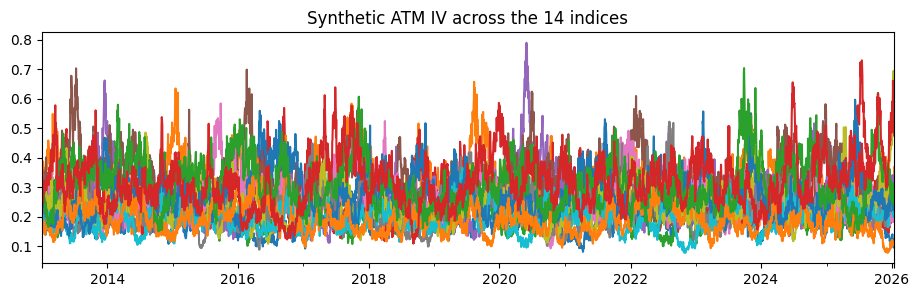

,trdDate,edate,expiryDate,exitDate,nTrdDays,qty,rtvega,pnlOpt,cost
78,2013-01-11,2013-01-11,2013-01-18,2013-01-18,5,0.003164,1.000000,0.000000,0.000106
79,2013-01-11,2013-01-14,2013-01-18,2013-01-18,4,0.003164,0.432641,-0.008610,0.000000
80,2013-01-11,2013-01-15,2013-01-18,2013-01-18,3,0.003164,0.598030,0.001097,0.000000
81,2013-01-11,2013-01-16,2013-01-18,2013-01-18,2,0.003164,0.826499,0.001119,0.000000
82,2013-01-11,2013-01-17,2013-01-18,2013-01-18,1,0.003164,0.249301,-0.003779,0.000000
83,2013-01-11,2013-01-18,2013-01-18,2013-01-18,0,0.003164,0.000000,-0.000433,0.000000


47,488 candidate entries; 489,608 path rows; 47,488 completed paths including the settlement tail.


,rows,features,has_secId
logret,428652,9,True
vol_ctc,285768,6,True
vol_irv,333396,7,False
volsurf,190512,4,True
beta1,571536,12,True
skew,190512,4,True
range0,285768,6,True
mom_aligned,238140,5,True


,date,ticker,value,feature,secId
0,2013-01-01,SPX,0.180094,iv_1m_50d,1
1,2013-01-01,NDX,0.284687,iv_1m_50d,2
2,2013-01-01,RUT,0.237628,iv_1m_50d,3
3,2013-01-01,SX5E,0.256550,iv_1m_50d,4
4,2013-01-01,DAX,0.248917,iv_1m_50d,5


DATA SOURCE = SYNTHETIC — input tables validated; shared processing starts below.


,rows,columns
idx_ref,14,"ticker, ccy, secId"
daily_raw,489608,"ticker, variant, contractSize, trdDate, sdate,..."
terminal_raw,47488,"ticker, variant, contractSize, trdDate, sdate,..."
fx_long,30618,"edate, ccy, fx_price"
vix_5m,515994,"timestamp, symbol, price"
us_schedule,3279,"market_open, market_close"
calendar,3402,"date, decision_at, feature_cutoff_at"
feature_clock,47488,"date, ticker, observation_date, available_at, ..."
feature_tables[logret],428652,"date, ticker, value, feature, secId"
feature_tables[vol_ctc],285768,"date, ticker, value, feature, secId"


,ticker,ccy,secId
0,SPX,USD,1
1,NDX,USD,2
2,RUT,USD,3
3,SX5E,EUR,4
4,DAX,EUR,5
5,CAC,EUR,6
6,FTSE,GBP,7
7,SMI,CHF,8
8,NKY,JPY,9
9,HSI,HKD,10


,ticker,trdDate,expiryDate,exitDate,nTrdDays,qty,rtvega,pnlOpt
349720,AS51,2013-01-01,2013-01-18,2013-01-15,13,0.003180,1.0,0.0
349731,AS51,2013-01-02,2013-01-18,2013-01-16,12,0.003166,1.0,0.0
349742,AS51,2013-01-03,2013-01-18,2013-01-17,11,0.003211,1.0,0.0
349753,AS51,2013-01-04,2013-01-18,2013-01-18,10,0.003104,1.0,0.0
349764,AS51,2013-01-07,2013-01-18,2013-01-18,9,0.003166,1.0,0.0


,date,ticker,value,feature,secId
0,2013-01-01,SPX,0.180094,iv_1m_50d,1
1,2013-01-01,NDX,0.284687,iv_1m_50d,2
2,2013-01-01,RUT,0.237628,iv_1m_50d,3
3,2013-01-01,SX5E,0.256550,iv_1m_50d,4
4,2013-01-01,DAX,0.248917,iv_1m_50d,5


,date,ticker,observation_date,available_at,quote_available_at
0,2013-01-01,SPX,NaT,NaT,NaT
1,2013-01-01,NDX,NaT,NaT,NaT
2,2013-01-01,RUT,NaT,NaT,NaT
3,2013-01-01,SX5E,NaT,NaT,NaT
4,2013-01-01,DAX,NaT,NaT,NaT


In [5]:
def validate_inputs(inputs):
    """Validate the shared source boundary without fabricating missing data."""
    schemas = {
        'idx_ref': ['secId', 'ticker', 'ccy'],
        'daily_raw': INTERVAL_KEY+['sdate', 'exitDate', 'variant', 'nTrdDays',
            'qty', 'rtvega', 'pnlOpt', 'cost', 'spot', 'delta', 'gamma', 'theta', 'vega', 'premium', 'ivol', 'contractSize'],
        'terminal_raw': PATH_KEY+['edate', 'exitDate', 'pnlOpt'],
        'fx_long': ['edate', 'ccy', 'fx_price'],
        'vix_5m': ['timestamp', 'symbol', 'price'],
        'us_schedule': ['market_open', 'market_close'],
        'calendar': ['date', 'decision_at'],
        'feature_clock': ['date', 'ticker', 'observation_date', 'available_at', 'quote_available_at'],
    }
    missing = set(schemas).union({'feature_tables'}).difference(inputs)
    if missing:
        raise ValueError(f'Input boundary: missing tables {sorted(missing)}')
    data = dict(inputs)
    for name, columns in schemas.items():
        frame = data[name]
        if not isinstance(frame, pd.DataFrame):
            raise ValueError(f'{name}: expected a DataFrame; connect its reader in B')
        absent = set(columns).difference(frame)
        if absent:
            raise ValueError(f'{name}: missing columns {sorted(absent)}')
        data[name] = frame.copy()
    for name, columns in {
        'daily_raw': ['trdDate', 'expiryDate', 'sdate', 'edate', 'exitDate'],
        'terminal_raw': ['trdDate', 'expiryDate', 'edate', 'exitDate'],
        'fx_long': ['edate'], 'calendar': ['date'],
        'feature_clock': ['date', 'observation_date'],
    }.items():
        for column in columns:
            values = pd.to_datetime(data[name][column], errors='raise')
            if isinstance(values.dtype, pd.DatetimeTZDtype) or not values.dropna().eq(values.dropna().dt.normalize()).all():
                raise ValueError(f'{name}.{column}: expected naive session-date labels')
            if column != 'observation_date' and values.isna().any():
                raise ValueError(f'{name}.{column}: missing date')
            data[name][column] = values
    for name, columns in {'calendar': ['decision_at'],
        'feature_clock': ['available_at', 'quote_available_at'],
        'vix_5m': ['timestamp'], 'us_schedule': ['market_open', 'market_close']}.items():
        for column in columns:
            if not isinstance(data[name][column].dtype, pd.DatetimeTZDtype):
                raise ValueError(f'{name}.{column}: require time-zone-aware timestamps')
            data[name][column] = data[name][column].dt.tz_convert('UTC')
    refs = data['idx_ref']
    if (len(refs) != 14 or refs[schemas['idx_ref']].isna().any().any()
            or not pd.api.types.is_integer_dtype(refs.secId.dtype)
            or refs.secId.duplicated().any() or refs.ticker.duplicated().any()
            or refs.ticker.eq('SKIP').any()):
        raise ValueError('idx_ref: require the chosen 14 distinct integer IDs/tickers and currencies')
    # Preserve integer IDs when the later SKIP row has no security ID.
    refs['secId'] = refs.secId.astype('Int64')
    for name, key in [('daily_raw', INTERVAL_KEY), ('terminal_raw', PATH_KEY),
                      ('fx_long', ['edate', 'ccy']), ('calendar', ['date']),
                      ('feature_clock', ['date', 'ticker'])]:
        frame = data[name]
        if frame[key].isna().any().any() or frame.duplicated(key).any():
            raise ValueError(f'{name}: null or duplicate identity {key}')
    for name in ['daily_raw', 'terminal_raw']:
        frame = data[name]
        if not frame.ticker.isin(refs.ticker).all():
            raise ValueError(f'{name}: ticker outside idx_ref')
        for column in ['secId', 'ccy']:
            if column in frame and not frame[column].eq(frame.ticker.map(refs.set_index('ticker')[column])).all():
                raise ValueError(f'{name}: {column} disagrees with idx_ref')
    daily = data['daily_raw'].sort_values(INTERVAL_KEY)
    data['daily_raw'] = daily
    if not (np.isfinite(daily.contractSize) & daily.contractSize.gt(0)).all():
        raise ValueError('daily_raw: require positive historical contractSize for option Greeks')
    opening = daily.loc[daily.edate.eq(daily.trdDate)]
    if (not daily.variant.eq(VARIANT).all() or opening.duplicated(['ticker', 'trdDate']).any()
            or opening.empty or daily.groupby(PATH_KEY).size().size != len(opening)
            or not pd.api.types.is_integer_dtype(daily.nTrdDays.dtype)
            or not daily.nTrdDays.ge(0).all() or not opening.nTrdDays.ge(M1_ROLL_DAYS).all()
            or not daily.trdDate.le(daily.edate).all() or not daily.edate.le(daily.exitDate).all()
            or not daily.exitDate.le(daily.expiryDate).all()):
        raise ValueError('daily_raw: invalid variant, opening, fixed expiry or nTrdDays')
    grouped = daily.groupby(PATH_KEY, sort=False)
    if (not grouped.exitDate.nunique().eq(1).all() or not grouped.qty.nunique().eq(1).all()
            or not grouped.nTrdDays.diff().dropna().eq(-1).all()
            or not daily.sdate.eq(grouped.edate.shift().fillna(daily.trdDate)).all()):
        raise ValueError('daily_raw: source gaps, changing exit/quantity or noncontiguous intervals')
    counts = grouped.size()
    expected = grouped.nTrdDays.first().clip(upper=HOLD)+1
    if counts.gt(expected).any():
        raise ValueError('daily_raw: path exceeds min(10 business days, expiry)')
    terminal = data['terminal_raw']
    if not terminal.edate.eq(terminal.exitDate).all():
        raise ValueError('terminal_raw: only completed paths belong in /trd')
    calendar = data['calendar'].sort_values('date')
    # Freeze every model input at the previous research EOD.
    calendar['feature_cutoff_at'] = calendar.decision_at.shift(1)
    data['calendar'] = calendar
    entries = calendar.loc[calendar.decision_at.notna(), 'date']
    if (entries.empty or not opening.trdDate.isin(entries).all()
            or not daily.edate.isin(calendar.date).all()):
        raise ValueError('calendar: missing declared decision or P&L dates')
    clock = data['feature_clock']
    required_keys = pd.MultiIndex.from_frame(opening[['trdDate', 'ticker']].rename(columns={'trdDate': 'date'}))
    clock_index = pd.MultiIndex.from_frame(clock[['date', 'ticker']])
    if not required_keys.isin(clock_index).all():
        raise ValueError('feature_clock: an opening candidate has no availability row')
    cutoffs = clock.date.map(calendar.set_index('date').feature_cutoff_at)
    has_observation = clock.observation_date.notna()
    if (not clock.date.isin(entries).all()
            or not clock.loc[has_observation, 'observation_date'].lt(clock.loc[has_observation, 'date']).all()
            or not clock.loc[has_observation, 'observation_date'].isin(calendar.date).all()
            or cutoffs[has_observation].isna().any()
            or clock.loc[has_observation, ['available_at', 'quote_available_at']].isna().any().any()
            or not clock.loc[has_observation, 'available_at'].le(cutoffs[has_observation]).all()
            or not clock.loc[has_observation, 'quote_available_at'].le(cutoffs[has_observation]).all()):
        raise ValueError('feature_clock: observations and quotes must be available by the t-1 EOD cutoff')
    schedule = data['us_schedule']
    if (not isinstance(schedule.index, pd.DatetimeIndex) or schedule.index.tz is not None
            or not schedule.index.is_unique or not schedule.index.is_monotonic_increasing
            or schedule[['market_open', 'market_close']].isna().any().any()
            or not schedule.market_open.lt(schedule.market_close).all()
            or not schedule.market_close.is_monotonic_increasing):
        raise ValueError('us_schedule: invalid ordered US sessions')
    if not isinstance(data['feature_tables'], dict) or set(data['feature_tables']) != set(FEATURE_NAMES):
        raise ValueError('feature_tables: supply exactly the FEATURE_NAMES families')
    feature_tables = {}
    for family, names in FEATURE_NAMES.items():
        table = data['feature_tables'][family]
        required = {'date', 'ticker', 'feature', 'value'} | (set() if family == 'vol_irv' else {'secId'})
        if not isinstance(table, pd.DataFrame) or required.difference(table):
            raise ValueError(f'feature_tables[{family}]: expected {sorted(required)}')
        if set(table.feature) != set(names):
            raise ValueError(f'feature_tables[{family}]: columns must match FEATURE_NAMES[{family}]')
        feature_tables[family] = table.copy()
        feature_tables[family]['date'] = pd.to_datetime(table.date, errors='raise')
    data['feature_tables'] = feature_tables
    return data


if DATA_SOURCE == 'synthetic':
    inputs = make_synthetic_inputs()
elif DATA_SOURCE == 'real':
    inputs = load_real_inputs()
else:
    raise ValueError('DATA_SOURCE must be synthetic or real')
inputs = validate_inputs(inputs)
idx_ref = inputs['idx_ref']
daily_raw, terminal_raw = inputs['daily_raw'], inputs['terminal_raw']
feature_tables, fx_long = inputs['feature_tables'], inputs['fx_long']
vix_5m, us_schedule = inputs['vix_5m'], inputs['us_schedule']
calendar, feature_clock = inputs['calendar'], inputs['feature_clock']
TICKERS = idx_ref.ticker.tolist()
CANDIDATES = sorted(TICKERS+['SKIP'])
dates = pd.DatetimeIndex(calendar.date)
entry_dates = pd.DatetimeIndex(calendar.loc[calendar.decision_at.notna(), 'date'])
opening_raw = daily_raw.loc[daily_raw.edate.eq(daily_raw.trdDate)]

print(f'DATA SOURCE = {DATA_SOURCE.upper()} — input tables validated; shared processing starts below.')
inventory = {name: {'rows': len(table), 'columns': ', '.join(map(str, table.columns))}
             for name, table in inputs.items() if isinstance(table, pd.DataFrame)}
inventory.update({f'feature_tables[{family}]': {'rows': len(table), 'columns': ', '.join(table.columns)}
                  for family, table in feature_tables.items()})
display(pd.DataFrame(inventory).T)
display(idx_ref)
display(opening_raw[PATH_KEY+['exitDate', 'nTrdDays', 'qty', 'rtvega', 'pnlOpt']].head())
display(feature_tables['volsurf'].head())
display(feature_clock.head())

## 1. Shared pipeline — Convert units once; build labels separately from the candidate universe

Keep `unit_rtvega` source scaling. Attach currency and convert each native interval
P&L using that interval's `edate` FX, exactly once. Then divide by **opening USD
maturity-adjusted vega** to express cash flow per dollar of entry risk:

\[
d_{t,u}=\frac{w\,\mathrm{pnlOpt}_{t,u}\,FX_u}
                   {|\mathrm{rtvega}_{t,t}|FX_t},\qquad w=-1.
\]

Entry costs use `abs(w)`, not the short sign. `qty` has already been applied
inside source P&L and Greeks; never multiply by it again. The denominator above
is a strategy risk-budget convention, **not** another `qty_one` normalization.

The paper's label is retained:
\[
G_t=\sum_u d_{t,u},\quad D_t=\sqrt{\sum_u\min(d_{t,u},0)^2},\quad
z_t=G_t/(D_t+10^{-8}).
\]

Labels are gross of costs; gate and portfolio cash flows subtract the supplied
entry cost. Daily marks miss intraday drawdowns, so this is a daily-resolution
adaptation of the paper's minute-path target. The score is not a return forecast.
The opening table defines the universe; `z` is unavailable until `exitDate`.

Path length comes from saved `nTrdDays`: expected rows are
`min(10, opening_nTrdDays) + 1`, including entry. The boundary checks interval
continuity and a one-business-day decrease at each mark. This handles actual
market holidays without inferring them from a synthetic weekday calendar.
An opening with an unfinished exit remains in the candidate universe; its
label stays missing until the declared exit and complete mark path are present.

In [6]:
def prepare_paths(raw, references, fx_rates):
    """Validate the single-leg unit-rtvega boundary and produce USD risk-unit flows."""
    required = set(INTERVAL_KEY + ['sdate', 'exitDate', 'qty', 'rtvega', 'pnlOpt', 'cost'])
    if required.difference(raw):
        raise ValueError(f'Missing UPNL fields: {sorted(required.difference(raw))}')
    if raw[INTERVAL_KEY].isna().any().any() or raw.duplicated(INTERVAL_KEY).any():
        raise ValueError('Null or duplicate UPNL identity')
    data = raw.drop(columns=['secId', 'ccy'], errors='ignore').merge(
        references[['ticker', 'secId', 'ccy']], on='ticker', validate='many_to_one')
    data = data.merge(fx_rates, on=['edate', 'ccy'], how='left', validate='many_to_one')
    if not np.isfinite(data[['pnlOpt', 'cost', 'qty', 'fx_price']]).all().all():
        raise ValueError('Non-finite cash flow, source quantity or exact-date FX')
    if not (data.qty.gt(0) & data.fx_price.gt(0) & data.cost.ge(0)).all():
        raise ValueError('Invalid quantity, FX or cost sign')
    data['sourceQty'] = data.qty
    data['struct_wgt'] = STRUCTURE_WEIGHT
    data['tradeOpen'] = data.edate.eq(data.trdDate)
    opening = data.loc[data.tradeOpen].copy()
    if opening.duplicated(PATH_KEY).any() or not opening.rtvega.gt(0).all():
        raise ValueError('Invalid opening risk unit')
    opening['entry_risk_usd'] = opening.rtvega.abs()*opening.fx_price
    data = data.merge(opening[PATH_KEY + ['entry_risk_usd']], on=PATH_KEY,
                      how='left', validate='many_to_one')
    if not data.entry_risk_usd.gt(0).all():
        raise ValueError('Missing opening row / invalid entry risk')
    data['gross_per_risk'] = data.struct_wgt*data.pnlOpt*data.fx_price/data.entry_risk_usd
    data['cost_per_risk'] = data.struct_wgt.abs()*data.cost*data.fx_price/data.entry_risk_usd
    data['net_per_risk'] = data.gross_per_risk-data.cost_per_risk
    return data, opening


flows, opening = prepare_paths(daily_raw, idx_ref, fx_long)
labels = flows.assign(down2=np.minimum(flows.gross_per_risk, 0)**2).groupby(PATH_KEY).agg(
    gross=('gross_per_risk', 'sum'), downside2=('down2', 'sum'),
    label_available=('edate', 'max'), exitDate=('exitDate', 'first'),
    net=('net_per_risk', 'sum'), observed_intervals=('edate', 'size'))
expected_intervals = flows.groupby(PATH_KEY).nTrdDays.first().clip(upper=HOLD)+1
complete = labels.label_available.eq(labels.exitDate) & labels.observed_intervals.eq(expected_intervals)
labels['z'] = (labels.gross/(np.sqrt(labels.downside2)+1e-8)).where(complete)
labels['label_available'] = labels.label_available.where(complete)
base = opening.merge(labels[['gross', 'net', 'z', 'label_available']].reset_index(),
                     on=PATH_KEY, how='left', validate='one_to_one')
base = base.rename(columns={'trdDate': 'date', 'ticker': 'candidate'}).set_index(['date', 'candidate'])
skip = pd.DataFrame(index=pd.MultiIndex.from_product([entry_dates, ['SKIP']], names=base.index.names))
skip[['gross', 'net', 'z']] = 0.
# All 15 rows share query availability: do not remove only the slower labels.
skip['label_available'] = base.label_available.groupby(level='date').max().reindex(entry_dates).to_numpy()
panel = pd.concat([base, skip]).sort_index()
row_dates = panel.index.get_level_values('date')
real = panel.index.get_level_values('candidate') != 'SKIP'
display(panel[['secId', 'ccy', 'gross', 'z', 'label_available']].head(len(CANDIDATES)))

secId  ccy     gross         z label_available
date       candidate                                                
2013-01-01 AS51          11  AUD  0.028559  1.341068      2013-01-15
           CAC            6  EUR  0.030278  2.017829      2013-01-15
           DAX            5  EUR  0.027243  0.724092      2013-01-15
           FTSE           7  GBP  0.025842  2.897429      2013-01-15
           HSI           10  HKD -0.004727 -0.110958      2013-01-15
           IBEX          14  EUR  0.036855  1.013630      2013-01-15
           KOSPI         12  KRW  0.019839  2.296280      2013-01-15
           NDX            2  USD  0.031258  0.727311      2013-01-15
           NKY            9  JPY  0.029687  3.052428      2013-01-15
           RUT            3  USD  0.022898  0.585164      2013-01-15
           SKIP        <NA>  NaN  0.000000  0.000000      2013-01-15
           SMI            8  CHF  0.022329  0.686452      2013-01-15
           SPX            1  USD  0.017647  1.183240      2013-01-15
           SX5E           4  EUR  0.024385  0.442446      2013-01-15
           TSX           13  CAD  0.033342  4.231219      2013-01-15

## 2. Persisted feature families we can actually map

The loader has supplied observations in the **documented long schemas** below.
The source's exact EWMA helper conventions are not published in the guide:
this generator explicitly uses pandas `ewm(span=n, adjust=False)` with full
warm-up. It is a coherent stand-in, not a claim to reproduce Qbit's helper code.
The real loader replaces these tables with persisted values, without recomputing them.

| Family | Kept observations | Paper-style group |
|---|---|---|
| `logret` | All documented 1/2/3/5/10/21/63/252/504 returns | `spx` (here: each candidate's index) |
| `vol_ctc`, `vol_irv` | All documented windows | `rv_iv` |
| `volsurf` | 1M 25/50/75-delta IV and 1M/3M slope | `vol_surface` |
| `beta1` | Beta, R² and residual volatility for 21/63/126/252 | `spx` |
| Five-minute VIX / VVIX observations | Prior US-session levels, 5/21-session changes, 252-session percentiles and VIX 60-session z-score | `vix` (common to every candidate) |
| `skew` | Mean-minus-median divided by sample SD, all four windows | `higher_moments` |
| `range0`, `mom_aligned` | All documented windows | `trend` |
| Opening UPNL | Unit-option Greeks, source premium, IV and maturity | `position` |
| Completed UPNL history | Premium-normalized returns, rolling Sharpe, moments, cumulative-gross drawdowns and tails | `strategy_stats` |
| Explicit ranks / products | IV–RV, exposures × market conditions | `intra_strategy` / `regime` |

VIX and VVIX are available in your data every five minutes during US market
hours. The `vix_5m` input table represents that feed; it does not
invent a persisted Qbit feature family or storage path. As you chose, use the
**previous completed US session**, not a current-day intraday snapshot. The
synthetic feed samples regular NYSE sessions through the close, including DST
and early closes. This is an explicit sample clock, not a claim about your
vendor's full VIX dissemination hours or official index closing calculations.

Use the price sampled at that session's close as the daily-close proxy. Its
timestamp is also its availability time in this synthetic feed. An absent
closing sample remains missing, even if an earlier five-minute sample exists.
Real bar timestamps must be converted to the time the observation was actually
available; a bar-start timestamp cannot stand in for its closing-price time.
The fake levels produced in C are positive observations linked to the synthetic market,
not an implementation of CBOE's VIX or VVIX construction.

We omit unconfirmed VIX tenors/futures, macro, intraday-morning and order-book inputs.
`iv_skew_1m`/`iv_smile_1m` and `composite` have insufficient formula detail in
the guide to recreate their precise helpers. The persisted `rpnl_*` families
refer to **different multi-leg structures**, so they are not renamed as this
short put's history. Their internal two-observation shift must not be repeated
if you later add them. `trddays` also names those other structures; this example
uses this put's own opening `nTrdDays`.

In [7]:
def us_session_closes(observations, schedule):
    """Take exact closing samples from timestamped, already-available prices."""
    if not isinstance(observations.timestamp.dtype, pd.DatetimeTZDtype):
        raise ValueError('VIX/VVIX timestamps must include a time zone')
    if (observations.timestamp.isna().any()
            or observations.duplicated(['timestamp', 'symbol']).any()
            or not observations.symbol.isin(['VIX', 'VVIX']).all()
            or not np.isfinite(observations.price).all()
            or observations.price.le(0).any()):
        raise ValueError('Invalid VIX/VVIX observation identity or price')
    samples = observations.pivot(index='timestamp', columns='symbol', values='price')
    return samples.reindex(index=pd.DatetimeIndex(schedule.market_close),
                           columns=['VIX', 'VVIX']).set_axis(schedule.index)


vix_closes = us_session_closes(vix_5m, us_schedule)
vix_features = vix_closes.copy()
for symbol in ['VIX', 'VVIX']:
    for window in [5, 21]:
        vix_features[f'{symbol}_{window}d_pct_change'] = vix_closes[symbol].pct_change(window, fill_method=None)
    # Paper/v1 definition: fraction of the strictly PREVIOUS 252 closes below today's.
    vix_features[f'{symbol}_1y_percentile'] = vix_closes[symbol].rolling(253).apply(
        lambda values: np.mean(values[:-1] < values[-1]), raw=True)
vix_features['vix_z_60d'] = ((vix_closes.VIX-vix_closes.VIX.rolling(60).mean())
                            / vix_closes.VIX.rolling(60).std().replace(0, np.nan))
display(vix_5m.head())
display(vix_features.tail())

,timestamp,symbol,price
0,2013-01-02 14:30:00+00:00,VIX,20.524114
1,2013-01-02 14:30:00+00:00,VVIX,87.459949
2,2013-01-02 14:35:00+00:00,VIX,20.669290
3,2013-01-02 14:35:00+00:00,VVIX,95.144573
4,2013-01-02 14:40:00+00:00,VIX,20.611596


symbol,VIX,VVIX,VIX_5d_pct_change,VIX_21d_pct_change,VIX_1y_percentile,VVIX_5d_pct_change,VVIX_21d_pct_change,VVIX_1y_percentile,vix_z_60d
2026-01-08,12.125546,70.718854,-0.008013,-0.090674,0.023810,0.082398,-0.043677,0.047619,-1.041791
2026-01-09,10.811593,70.352854,-0.220369,-0.255314,0.000000,-0.086632,-0.053135,0.043651,-1.235030
2026-01-12,9.405790,62.409538,-0.328630,-0.366356,0.000000,-0.240977,-0.232050,0.000000,-1.437018
2026-01-13,11.148494,67.304278,-0.093935,-0.290178,0.015873,-0.106619,-0.166861,0.023810,-1.088054
2026-01-14,11.895354,79.479134,-0.043897,-0.174233,0.023810,0.086469,-0.028672,0.166667,-0.928215


## 3. Point-in-time feature matrix; visible ranks and products

Attach the **exact-date** observation selected by each row of `feature_clock` to
each entry; missing observations remain missing, rather than forward filling stale
data. `vol_irv` first receives `secId` through a validated `idxRef` join. Preserve
`family__feature` names to prevent collisions between families.

VIX/VVIX use their own **US session calendar**: choose the last scheduled US
close at or before **EOD t−1**, the shared `feature_cutoff_at` derived from
the research calendar. Tuesday EOD trading uses Monday's US close,
without an accidental second lag. A US holiday therefore retains
the preceding completed session, while a missing scheduled closing observation
stays missing. Rolling windows count US sessions, not all synthetic weekdays;
calculate them on the session series first, then align once to entry dates.
No pre-2013 observations are invented to fill the natural warm-up gaps.

Their nine features retain native volatility-point levels, relative changes,
within-series percentiles and the explicitly defined z-score. They are CS:
each value is copied to all 14 indices **and SKIP**. No cross-index ranking is
applied to these common values. Trees can condition candidate comparisons on
this context; the named exposure products below also vary across candidates.

All position descriptors come from the exact **prior observation date** using
the same join as the persisted features. The row's day-t opening quote is used
only for execution/labels. Calendar weekday/month also refer to t−1.

All four Greeks use the same conversion:
`position_<greek> = STRUCTURE_WEIGHT * saved_greek / (qty * contractSize)`.
This removes the source's position sizing and contract multiplier, recovering
the **unit-option Greek** before applying the short-position sign (−1).
Delta is dimensionless: about −0.25 for the synthetic long-source put and
+0.25 for the short. Gamma is per index point, theta remains annual, and vega
is per unit decimal IV, following the input contract. Gamma has no spot²
multiplier, theta is not divided by 252, and vega is not multiplied by IV.
These descriptor conversions **do not change P&L normalization**.
The perfectly targeted synthetic delta can be constant and removed by S2;
real strike discreteness may produce departures from the target. The existing
S2 variance rule applies to the raw Greek units too; no rescaling is added to
force retention. `position_rtvega` remains a separate source-risk descriptor,
approximately constant by construction, so S2 may correctly remove it.

### Strategy history: the paper's premium-normalized statistics

For each completed candidate trade, compute **ROM = gross P&L / entry premium**.
Despite the name `returns_on_margin`, the paper's denominator is entry premium,
not broker margin or rtvega. In the code, both are USD cash amounts for the same
saved source quantity: `gross_usd = labels.gross * entry_risk_usd` and
`premium_usd = opening.premium * opening.fx_price`. Gross uses each mark's FX;
premium uses entry FX. Source rtvega normalization cancels in ROM and is never
undone in the P&L ledger. Positive finite entry premium is required. Gross is
before costs, funding and hedge P&L, matching the label's gross convention.

**Multi-day adaptation you chose:** each rolling window includes **all trades
completed within the last N research trading days**, equally weighted. Ten-day
trades enter history only at completion. Several cohorts expiring together
remain separate observations; no-exit dates add no zero-return observations.
`returns_on_margin` is the mean ROM of that date's completions and is missing
on a no-exit date. For example, +10/100 and −10/50 produce ROMs +0.10 and −0.20:
both enter rolling statistics, while that day's current ROM is −0.05.

| Feature | Formula at the observation close |
|---|---|
| `returns_on_margin` | Mean ROM of that day's completed cohorts |
| `rom_diff_to_spx` | Current ROM minus that day's one-day SPX simple return |
| `rom_roll_avg_30d`, `rom_roll_std_30d`, `rom_roll_skew_30d` | Mean, sample SD, pandas unbiased skew of all ROMs completed in 30 sessions |
| `sharpe_ratio_rom_60d` | 60-session ROM mean / sample SD, unannualized; no risk-free subtraction |
| `sharpe_ratio_rom_std_60d` | Sample SD of the last 60 daily rolling Sharpe values (nested window) |
| `win_rate_30d` | Fraction of completed trades with ROM > 0 in 30 sessions; zero is not a win |
| `stability_coef_60d` | Squared Pearson correlation of ROM with completion-session index over 60 sessions; same-date cohorts share the time index |
| `tail_ratio_rom_30d` | abs(Q95 ROM) / abs(Q05 ROM), linear empirical quantiles over 30 sessions |
| `drawdown_63`, `drawdown_126`, `drawdown_252` | `(rolling_peak(C) − C) / rolling_peak(C)` |
| `distance_from_max_63`, `distance_from_max_126`, `distance_from_max_252` | `C − rolling_peak(C)`, signed USD distance |
| `prior_day_strategy_drawdown_max_5d` | Five-session drawdown, aligned to t−1 once; no second rolling maximum |

`C` sums completed **gross USD P&L** from the history start (2013 in the example),
with no starting NAV. Multiple completions sum; a no-exit day leaves C unchanged.
It describes each index's source-normalized candidate trades, independently of
the ranker's selected trades or calibrated allocations. Dollar distances retain
that Qbit source-size convention; they are not one-SPX-contract dollar distances.
Negative cumulative peaks retain the paper's literal formula, even if the
result is negative. Zero denominators and undefined statistics remain missing.

Require the full N-session calendar span and the observations mathematically
needed by each estimator (e.g. two for sample SD, three for skew). A nested
60-day Sharpe SD requires 60 defined daily Sharpe observations. Stability is
also high for steadily decreasing ROM. The SPX difference retains the paper's
one-day benchmark formula: it is **not a matched-horizon excess return** for
v2's multi-day trades. Missing SPX observations remain missing.

The helper uses an ordinal session clock only to implement these windows with
pandas; it is not a model feature. Align all outputs to each candidate's prior
observation once, as with other features. No unfinished trade, day-t outcome or
future label-score mean enters history. These are derived UPNL features, not
persisted `rpnl_*` features. The code displays completed trades and their ROM
so the source-to-feature calculation is inspectable in either data mode.

Five named within-date ranks remain explicit columns, not blanket preprocessing.
The paper's ROM, Sharpe and drawdown ranks replace the old gross-mean rank; two
existing IV/RV ranks remain Qbit additions. `drawdown_63d_wd_rank` uses
`drawdown_63`, resolving the paper's spelling inconsistency. All use descending
average ranks. Real candidates occupy ranks 1–14 when all observations exist;
SKIP gets **14.5 = number of configured real candidates + 0.5**, adapting the
paper's 8.5 for eight candidates. The half-step is a fixed sentinel beyond the
real ranks, not a percentile, missing-value code or model prediction. It remains
14.5 if a day's real observations are missing. These are input features: the
model can still assign SKIP the highest predicted score and choose it.

All ordinary candidate-specific (PS) inputs on SKIP are **`np.nan`**, including
persisted index features, Greeks, premium, IV, maturity, rtvega and interaction
products. SKIP has no index/option to supply those observations. The explicit
exceptions are ROM=0 and the rank sentinel; shared calendar and VIX/VVIX context
are copied to SKIP. This follows the paper's missing-value convention. LightGBM
receives the numeric NaNs directly; real numerical zeros retain their meaning.
Every Greek product uses the signed unit-option Greek above.
The VVIX-percentile product still uses vega rather than the paper's delta-gap
factor, so it remains an adaptation. `gamma_x_rv2` keeps its RV² / 252 factor;
that division converts annualized variance, not the gamma input.
Every factor uses information frozen through t−1. For synchronous daily inputs,
`(delta * VIX).shift(1)` equals `delta.shift(1) * VIX.shift(1)`.
The code aligns each factor once, then multiplies; it does not lag an already
aligned product again. Source-unit differences remain documented separately.

In [8]:
GROUP_ORDER = ['calendar', 'spx', 'vix', 'vol_surface', 'rv_iv', 'higher_moments',
               'trend', 'position', 'strategy_stats', 'intra_strategy', 'regime']
FAMILY_GROUP = dict(logret='spx', beta1='spx', volsurf='vol_surface',
                    vol_ctc='rv_iv', vol_irv='rv_iv', skew='higher_moments',
                    range0='trend', mom_aligned='trend')


def ratio(a, b):
    return (a/b.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)


def combine_families(tables, references):
    """Validate source identities and enrich the documented legacy family."""
    parts = []
    for family, table in tables.items():
        part = table.copy()
        if family == 'vol_irv' and 'secId' not in part:
            part = part.merge(references[['ticker', 'secId']], on='ticker', how='left', validate='many_to_one')
        key = ['date', 'secId', 'ticker', 'feature']
        if set(key+['value']).difference(part):
            raise ValueError(f'{family}: missing schema fields')
        part['date'] = pd.to_datetime(part.date, errors='raise')
        if part[key].isna().any().any() or part.duplicated(key).any():
            raise ValueError(f'{family}: invalid feature identity')
        expected = references.set_index('ticker').secId
        if not part.secId.eq(part.ticker.map(expected)).all():
            raise ValueError(f'{family}: ticker/secId mismatch')
        part['value'] = pd.to_numeric(part.value, errors='raise').replace([np.inf, -np.inf], np.nan)
        part['column'] = family+'__'+part.feature
        part['_family'] = family
        parts.append(part)
    return pd.concat(parts, ignore_index=True)


features_long = combine_families(feature_tables, idx_ref)
wide = features_long.pivot(index=['date', 'ticker'], columns='column', values='value').sort_index()
aligned_clock = feature_clock.set_index(['date', 'ticker']).reindex(panel.index)
join_keys = pd.MultiIndex.from_arrays([
    aligned_clock.observation_date.to_numpy(), panel.index.get_level_values('candidate')],
    names=['date', 'ticker'])
X = wide.reindex(join_keys).set_axis(panel.index)
X.loc[~real] = np.nan
metadata = {c: dict(scope='PS', group=FAMILY_GROUP[c.split('__')[0]],
                   sources={FAMILY_GROUP[c.split('__')[0]]},
                   availability='previous session', definition='persisted '+c)
            for c in X}


def add_feature(name, values, group, definition, scope='PS', availability='prior observation, frozen through t-1'):
    series = pd.Series(values, index=panel.index, dtype=float).replace([np.inf, -np.inf], np.nan)
    if scope == 'PS':
        series.loc[~real] = np.nan
    X[name] = series
    metadata[name] = dict(scope=scope, group=group, sources={group},
                          availability=availability, definition=definition)


def align_us_context(features, schedule, decision_dates, decision_cutoffs):
    """Align scheduled prior closes; never substitute an older nonmissing quote."""
    cutoffs = pd.DatetimeIndex(decision_cutoffs)
    close_times = pd.DatetimeIndex(schedule.market_close)
    positions = close_times.searchsorted(cutoffs, side='right')-1
    positions[cutoffs.isna()] = -1
    expected_sessions = pd.DatetimeIndex([
        schedule.index[p] if p >= 0 else pd.NaT for p in positions])
    scheduled_close = pd.DatetimeIndex([
        close_times[p] if p >= 0 else pd.NaT for p in positions], tz='UTC')
    alignment = pd.DataFrame({'us_session': expected_sessions,
                              'scheduled_close': scheduled_close,
                              'information_cutoff': cutoffs}, index=decision_dates)
    return features.reindex(expected_sessions).set_axis(decision_dates), alignment


vix_at_entry, vix_alignment = align_us_context(vix_features, us_schedule, entry_dates,
    calendar.set_index('date').feature_cutoff_at.reindex(entry_dates))
for name in vix_features:
    add_feature(name, vix_at_entry[name].reindex(row_dates).to_numpy(), 'vix',
                'prior US session: '+name, scope='CS', availability='prior scheduled US close')
display(vix_alignment.loc['2024-07-03':'2024-07-08'])


# Prior candidate descriptors, never the execution-date row in panel.
prior_position = opening.set_index(['trdDate', 'ticker']).reindex(join_keys).set_axis(panel.index)
contract_quantity = prior_position.qty*prior_position.contractSize
for name, value in {
    'position_delta': STRUCTURE_WEIGHT*prior_position.delta/contract_quantity,
    'position_gamma': STRUCTURE_WEIGHT*prior_position.gamma/contract_quantity,
    'position_theta': STRUCTURE_WEIGHT*prior_position.theta/contract_quantity,
    'position_vega': STRUCTURE_WEIGHT*prior_position.vega/contract_quantity,
    'position_premium': prior_position.premium,
    'position_iv': prior_position.ivol,
    'position_nTrdDays': prior_position.nTrdDays,
    'position_rtvega': STRUCTURE_WEIGHT*prior_position.rtvega,
}.items():
    add_feature(name, value, 'position', name.removeprefix('position_'))

add_feature('iv_rv_gap', X.volsurf__iv_1m_50d-X.vol_ctc__vol_ctc_21, 'rv_iv', 'ATM IV minus 21-day realized vol')
add_feature('iv_rv_ratio', ratio(X.volsurf__iv_1m_50d, X.vol_ctc__vol_ctc_21), 'rv_iv', 'ATM IV / realized vol')
add_feature('rv_short_long', ratio(X.vol_ctc__vol_ctc_5, X.vol_ctc__vol_ctc_63), 'rv_iv', '5-day / 63-day realized vol')

def strategy_history(completed, history_dates, tickers, spx_return):
    """Paper statistics on completed cohorts in trailing research-session windows.

    Each completed trade has rom=gross_usd/premium_usd. An ordinal daily clock
    lets pandas' time windows include every same-day completion and empty
    session while counting the supplied research calendar, including holidays.
    Returned values are observation-date values; the caller aligns t−1 once.
    """
    clock = pd.to_datetime(np.arange(len(history_dates)), unit='D')
    parts = []
    for ticker in tickers:
        trades = completed.loc[completed.ticker.eq(ticker)]
        positions = history_dates.get_indexer(trades.label_available)
        if (positions < 0).any():
            raise ValueError('Completed trade date is outside the history calendar')
        events = pd.DataFrame({'rom': trades.rom.to_numpy(), 'session': positions},
                              index=clock[positions])
        # NaN marker at every session end: no fake zero-return trade on empty days.
        markers = pd.DataFrame({'rom': np.nan, 'session': np.arange(len(clock))}, index=clock)
        events = pd.concat([events, markers]).sort_index(kind='stable')
        session_end = ~events.index.duplicated(keep='last')

        def at_close(value, window):
            result = value.loc[session_end].set_axis(history_dates)
            return result.where(np.arange(len(history_dates)) >= window-1)

        rom = events.rom
        r30, r60 = rom.rolling('30D'), rom.rolling('60D')
        # Multiple completions: current ROM is their equal-weight mean;
        # rolling moments below still include each completed trade individually.
        current = trades.groupby('label_available').rom.mean().reindex(history_dates)
        result = pd.DataFrame({
            'returns_on_margin': current,
            'rom_diff_to_spx': current-spx_return.reindex(history_dates),
            'rom_roll_avg_30d': at_close(r30.mean(), 30),
            'rom_roll_std_30d': at_close(r30.std(ddof=1), 30),
            'rom_roll_skew_30d': at_close(r30.skew(), 30),
            'sharpe_ratio_rom_60d': at_close(ratio(r60.mean(), r60.std(ddof=1)), 60),
            'win_rate_30d': at_close(rom.gt(0).where(rom.notna()).rolling('30D').mean(), 30),
            'stability_coef_60d': at_close(r60.corr(events.session)**2, 60),
            'tail_ratio_rom_30d': at_close(ratio(r30.quantile(.95).abs(), r30.quantile(.05).abs()), 30),
        }, index=history_dates)
        result['sharpe_ratio_rom_std_60d'] = result.sharpe_ratio_rom_60d.rolling(60).std(ddof=1)
        # Gross USD from source-normalized trades, before costs; no NAV or label score.
        gross = trades.groupby('label_available').gross_usd.sum().reindex(history_dates, fill_value=0.)
        cumulative = gross.cumsum()
        for window in [5, 63, 126, 252]:
            peak = cumulative.rolling(window).max()
            drawdown = ratio(peak-cumulative, peak)
            if window == 5:
                result['prior_day_strategy_drawdown_max_5d'] = drawdown
            else:
                result[f'drawdown_{window}'] = drawdown
                result[f'distance_from_max_{window}'] = cumulative-peak
        result['ticker'] = ticker
        parts.append(result.rename_axis('date').reset_index())
    return pd.concat(parts, ignore_index=True).set_index(['date', 'ticker']).sort_index()


# A finished path's result is first recorded at its exit, not backdated to entry.
# Undo only the ledger's reporting divisor to recover matching USD cash-flow
# units for ROM and dollar distances; source qty/rtvega normalization stays intact.
entry_units = opening.set_index(PATH_KEY)
premium_usd = entry_units.premium*entry_units.fx_price
if not (np.isfinite(premium_usd) & premium_usd.gt(0)).all():
    raise ValueError('Strategy history requires finite, positive opening premium in USD')
completed = labels.loc[complete, ['gross', 'label_available']].copy()
completed['gross_usd'] = completed.gross*entry_units.entry_risk_usd
completed['premium_usd'] = premium_usd
completed['rom'] = completed.gross_usd/completed.premium_usd
completed = completed.reset_index()
spx_return = np.expm1(wide.xs('SPX', level='ticker').logret__logret_1).reindex(dates)
history = strategy_history(completed, dates, TICKERS, spx_return)
history_definitions = {
    'returns_on_margin': 'mean completed-cohort gross USD / entry premium USD on observation date',
    'rom_diff_to_spx': 'completed ROM minus same-observation-date one-day SPX simple return',
    'rom_roll_avg_30d': 'mean cohort ROM in trailing 30 research sessions',
    'rom_roll_std_30d': 'sample SD of cohort ROM in trailing 30 research sessions',
    'rom_roll_skew_30d': 'pandas unbiased skew of cohort ROM in trailing 30 research sessions',
    'sharpe_ratio_rom_60d': '60-session cohort ROM mean / sample SD; unannualized',
    'sharpe_ratio_rom_std_60d': '60-session sample SD of the daily rolling ROM Sharpe series',
    'win_rate_30d': 'fraction of completed cohorts with ROM > 0 in trailing 30 sessions',
    'stability_coef_60d': 'squared correlation of cohort ROM and completion-session index over 60 sessions',
    'tail_ratio_rom_30d': 'abs(Q95 cohort ROM) / abs(Q05 cohort ROM) over 30 sessions; linear quantiles',
    'prior_day_strategy_drawdown_max_5d': 'five-session drawdown on cumulative completed gross USD; align once',
}
for window in [63, 126, 252]:
    history_definitions[f'drawdown_{window}'] = f'(rolling {window}-session cumulative gross USD peak - cumulative gross USD) / peak'
    history_definitions[f'distance_from_max_{window}'] = f'cumulative gross USD - rolling {window}-session peak; signed dollars'
for name in history:
    add_feature(name, history[name].reindex(join_keys).to_numpy(),
                'strategy_stats', history_definitions[name],
                availability='completed exits through previous session')
X.loc[~real, 'returns_on_margin'] = 0.  # Explicit paper exception.
metadata['rom_diff_to_spx']['sources'].add('spx')
display(completed[['ticker', 'trdDate', 'label_available', 'gross_usd', 'premium_usd', 'rom']].head())

rank_sources = {
    'iv_rv_gap': 'iv_rv_gap',
    'volsurf__iv_1m_50d': 'volsurf__iv_1m_50d',
    'returns_on_margin': 'returns_on_margin',
    'sharpe_ratio_rom_60d': 'sharpe_ratio_rom_60d',
    'drawdown_63d': 'drawdown_63',  # Resolve the paper's inconsistent d suffix.
}
for output, source in rank_sources.items():
    ranks = X.loc[real, source].groupby(level='date').rank(ascending=False, method='average')
    name = output+'_wd_rank'
    add_feature(name, ranks.reindex(panel.index), 'intra_strategy', 'descending within-date rank of '+source)
    X.loc[~real, name] = len(TICKERS)+.5
    metadata[name]['sources'] |= metadata[source]['sources']
    metadata[name]['availability'] = metadata[source]['availability']

products = {
    'delta_x_return': ('position_delta', 'logret__logret_1'),
    'gamma_x_rv2': ('position_gamma', None),
    'vega_x_ivgap': ('position_vega', 'iv_rv_gap'),
    'ivgap_x_beta': ('iv_rv_gap', 'beta1__beta1_63'),
    'theta_x_term': ('position_theta', 'volsurf__iv_slope1m3m'),
    'delta_x_VIX': ('position_delta', 'VIX'),
    'vega_x_VIX_5d_pct_change': ('position_vega', 'VIX_5d_pct_change'),
    'vega_x_VVIX_1y_percentile': ('position_vega', 'VVIX_1y_percentile'),
}
for name, (left, right) in products.items():
    multiplier = X[right] if right else X.vol_ctc__vol_ctc_21**2/ANN
    add_feature(name, X[left]*multiplier, 'regime', left+' × '+(right or 'RV² / 252'))
    source_right = right or 'vol_ctc__vol_ctc_21'
    metadata[name]['sources'] |= metadata[left]['sources'] | metadata[source_right]['sources']
    metadata[name]['availability'] = ' × '.join(dict.fromkeys([
        metadata[left]['availability'], metadata[source_right]['availability']]))
prior_dates = pd.Series(calendar.date.shift().to_numpy(), index=calendar.date)
calendar_observation = pd.DatetimeIndex(prior_dates.reindex(row_dates))
for name, values in [('weekday', calendar_observation.weekday), ('month', calendar_observation.month)]:
    add_feature('calendar_'+name, values, 'calendar', name, scope='CS', availability='previous research session')
catalog = pd.DataFrame.from_dict(metadata, orient='index')
display(catalog.groupby(['group', 'scope']).size().rename('columns').to_frame())
display(catalog.loc[list(products), ['definition', 'scope']])
print(f'{X.shape[1]} candidate columns before S1–S5; no ticker/name encoding.')

,us_session,scheduled_close,information_cutoff
date,,,
2024-07-03,2024-07-02,2024-07-02 20:00:00+00:00,2024-07-02 23:00:00+00:00
2024-07-04,2024-07-03,2024-07-03 17:00:00+00:00,2024-07-03 23:00:00+00:00
2024-07-05,2024-07-03,2024-07-03 17:00:00+00:00,2024-07-04 23:00:00+00:00
2024-07-08,2024-07-05,2024-07-05 20:00:00+00:00,2024-07-05 23:00:00+00:00


,ticker,trdDate,label_available,gross_usd,premium_usd,rom
0,AS51,2013-01-01,2013-01-15,0.019977,0.020341,0.982071
1,AS51,2013-01-02,2013-01-16,0.018775,0.018949,0.990840
2,AS51,2013-01-03,2013-01-17,0.020379,0.020405,0.998709
3,AS51,2013-01-04,2013-01-18,0.019882,0.019971,0.995548
4,AS51,2013-01-07,2013-01-18,0.018942,0.018969,0.998561


,,columns
group,scope,
calendar,CS,2
higher_moments,PS,4
intra_strategy,PS,5
position,PS,8
regime,PS,8
rv_iv,PS,16
spx,PS,21
strategy_stats,PS,17
trend,PS,11


,definition,scope
delta_x_return,position_delta × logret__logret_1,PS
gamma_x_rv2,position_gamma × RV² / 252,PS
vega_x_ivgap,position_vega × iv_rv_gap,PS
ivgap_x_beta,iv_rv_gap × beta1__beta1_63,PS
theta_x_term,position_theta × volsurf__iv_slope1m3m,PS
delta_x_VIX,position_delta × VIX,PS
vega_x_VIX_5d_pct_change,position_vega × VIX_5d_pct_change,PS
vega_x_VVIX_1y_percentile,position_vega × VVIX_1y_percentile,PS


105 candidate columns before S1–S5; no ticker/name encoding.


## 4. Training, tuning, gate and prediction dates — purge unfinished labels

Use your available history from **2013**, with the paper's expanding-history
method and unchanged 2021–2025 annual prediction windows. The earlier history
start is a data adaptation; no early rows are discarded merely because a
long-window feature is still warming up. S1–S5 handle those missing values.
For each 1 January prediction boundary: the last six prior months are the gate
hold-out; the preceding six are hyperparameter validation, with their final
three used for early stopping. Search fitting ends before tuning; refit fitting
ends before early stopping. Feature selection uses the paper's broader pre-gate
window, including validation dates: tuning is **not a fully nested evaluation**.

An entry before a boundary is insufficient. Every real candidate's label in a
training query must also have completed **strictly before** that boundary.
The same rule applies to validation, early stopping, gate calibration and S5
prefixes. Predictions need no label, so still-open year-end entries remain
eligible. Frozen grade cutpoints use pooled real candidates from fitting rows,
never within-day label ranks. SKIP gets the grade containing zero.

In [9]:
def date_roles(year, history_start='2013-01-01'):
    boundary = pd.Timestamp(year=year, month=1, day=1)
    gate_start = boundary-pd.DateOffset(months=6)
    tune_start = gate_start-pd.DateOffset(months=6)
    stop_start = gate_start-pd.DateOffset(months=3)
    start = pd.Timestamp(history_start)
    return dict(start=start, tune_start=tune_start, stop_start=stop_start,
                gate_start=gate_start, prediction_start=boundary,
                prediction_end=boundary+pd.DateOffset(years=1))


def inference_mask(start, end):
    return (row_dates >= start) & (row_dates < end)


def period_mask(start, end):
    # Purge whole queries; preserve comparable candidate sets.
    known = panel.z.notna() & panel.label_available.lt(end)
    query_known = known.groupby(level='date').transform('all').to_numpy()
    return inference_mask(start, end) & query_known


def grade_cuts(mask):
    return panel.loc[mask & real, 'z'].quantile(GRADE_QUANTILES, interpolation='linear').to_numpy()


def grades(z, cuts):
    return np.searchsorted(cuts, np.asarray(z), side='left').astype(np.int32)




timeline = pd.DataFrame({year: date_roles(year) for year in PREDICTION_YEARS}).T
display(timeline)
example_roles = date_roles(2021)
example_cuts = grade_cuts(period_mask(example_roles['start'], example_roles['tune_start']))
display(pd.Series(example_cuts, index=GRADE_QUANTILES, name='2021 search-fit grade cuts'))
print('SKIP grade:', grades([0.], example_cuts)[0])

,start,tune_start,stop_start,gate_start,prediction_start,prediction_end
2021,2013-01-01,2020-01-01,2020-04-01,2020-07-01,2021-01-01,2022-01-01
2022,2013-01-01,2021-01-01,2021-04-01,2021-07-01,2022-01-01,2023-01-01
2023,2013-01-01,2022-01-01,2022-04-01,2022-07-01,2023-01-01,2024-01-01
2024,2013-01-01,2023-01-01,2023-04-01,2023-07-01,2024-01-01,2025-01-01
2025,2013-01-01,2024-01-01,2024-04-01,2024-07-01,2025-01-01,2026-01-01


0.1    -0.917043
0.4     0.771499
0.6     1.843275
0.9    16.582147
Name: 2021 search-fit grade cuts, dtype: float64

SKIP grade: 1


## 5. S1–S5 feature selection

Apply the source thresholds in order. S3 is a **screen**, not a transformation
of the features fed to LightGBM. CS relevance is cross-day Spearman correlation
with the day-mean label. PS relevance is the median of within-day Spearman
correlations. SKIP is excluded from selection statistics.

S4 clusters only within the same scope at $|\rho|\ge0.85$. A graph connected
component is our explicit choice for the source's unspecified clustering rule.
Keep the strongest representative and apply source group caps. S5 reruns these
steps on three expanding prefixes and requires survival in at least two folds.
The final set also passes S1–S4 on the complete pre-gate selection window.

Every dropped column has a recorded reason; the notebook does not force the
synthetic feature count to match the paper's reported 50–60 survivors.

For v2, original group caps map to the groups listed above: `position=8`,
`vol_surface=4`, `vix=6`, `calendar=8`, other included groups `=5`. These limits are
from the paper, not a new feature budget. Across-index relevance is the median
within-day Spearman correlation for PS columns. Spearman is used to select
columns; the numeric model inputs themselves are not replaced with these ranks.

In [10]:
def relevance(frame, target, columns):
    result = pd.Series(np.nan, index=columns, dtype=float)
    cs = [c for c in columns if catalog.at[c, 'scope'] == 'CS']
    ps = [c for c in columns if catalog.at[c, 'scope'] == 'PS']
    day_target = target.groupby(level='date').mean()
    if cs:
        daily = frame[cs].groupby(level='date').first()
        result.loc[cs] = daily.corrwith(day_target, method='spearman')
    if ps:
        # Pairwise-complete Spearman per feature/day; missingness changes y ranks.
        correlations = {}
        for c in ps:
            valid = frame[c].notna() & target.notna()
            pair = pd.DataFrame({'x': frame.loc[valid, c], 'y': target.loc[valid]})
            ranked = pair.groupby(level='date').rank(method='average')
            centered = ranked-ranked.groupby(level='date').transform('mean')
            numerator = (centered.x*centered.y).groupby(level='date').sum()
            denominator = np.sqrt(centered.x.pow(2).groupby(level='date').sum()*
                                  centered.y.pow(2).groupby(level='date').sum())
            daily_corr = ratio(numerator, denominator).dropna()
            correlations[c] = daily_corr.median() if not daily_corr.empty else np.nan
        result.loc[ps] = pd.Series(correlations)
    return result


def select_s1_s4(mask, columns, correlation_threshold=.85):
    frame = X.loc[mask & real, columns]
    target = panel.loc[frame.index, 'z']
    audit = pd.DataFrame(index=columns)
    audit['null_rate'] = frame.isna().mean()
    audit['variance'] = frame.var()
    audit['modal_fraction'] = frame.apply(lambda s: s.value_counts(normalize=True).max())
    audit['reason'] = 'kept'
    audit.loc[audit.null_rate > .30, 'reason'] = 'S1 missingness'
    s2 = (audit.variance < 1e-6) | (audit.modal_fraction > .99)
    audit.loc[(audit.reason == 'kept') & s2, 'reason'] = 'S2 near-constant'
    candidates = audit.index[audit.reason == 'kept'].tolist()
    audit['relevance'] = relevance(frame, target, candidates)
    weak = audit.relevance.isna() | (audit.relevance.abs() < .05)
    audit.loc[(audit.reason == 'kept') & weak, 'reason'] = 'S3 relevance'

    def priority(c):
        return (-abs(audit.at[c, 'relevance']), GROUP_ORDER.index(catalog.at[c, 'group']),
                audit.at[c, 'null_rate'], c)

    for scope in ['CS', 'PS']:
        columns_scope = [c for c in audit.index[audit.reason == 'kept'] if catalog.at[c, 'scope'] == scope]
        if not columns_scope:
            continue
        data = frame[columns_scope]
        if scope == 'CS':
            data = data.groupby(level='date').first()
        corr = data.corr(method='spearman').abs().fillna(0)
        adjacency = corr.to_numpy() >= correlation_threshold
        np.fill_diagonal(adjacency, True)
        _, components = connected_components(csr_matrix(adjacency), directed=False)
        for component in np.unique(components):
            members = [c for c, label in zip(columns_scope, components) if label == component]
            winner = min(members, key=priority)
            for c in members:
                if c != winner:
                    audit.at[c, 'reason'] = 'S4 redundancy'
    caps = {'position': 8, 'vol_surface': 4, 'vix': 6, 'calendar': 8}
    for group in GROUP_ORDER:
        members = [c for c in audit.index[audit.reason == 'kept'] if catalog.at[c, 'group'] == group]
        for c in sorted(members, key=priority)[caps.get(group, 5):]:
            audit.at[c, 'reason'] = 'S4 group cap'
    return audit.index[audit.reason == 'kept'].tolist(), audit


def select_features(mask, drop_groups=(), drop_features=(), correlation_threshold=.85):
    columns = [c for c in X if c not in drop_features and
               not (catalog.at[c, 'sources'] & set(drop_groups))]
    selected, audit = select_s1_s4(mask, columns, correlation_threshold)
    training_dates = row_dates[mask].unique().sort_values()
    folds = np.array_split(training_dates, 3)  # Three equal date partitions; source leaves endpoints open.
    survivors = Counter()
    for fold in folds:
        fold_known = panel.z.notna() & panel.label_available.le(fold[-1])
        fold_known = fold_known.groupby(level='date').transform('all').to_numpy()
        fold_mask = mask & (row_dates <= fold[-1]) & fold_known
        fold_features, _ = select_s1_s4(fold_mask, columns, correlation_threshold)
        survivors.update(fold_features)
    audit['fold_survival'] = pd.Series(survivors).reindex(audit.index, fill_value=0)
    audit.loc[(audit.reason == 'kept') & (audit.fold_survival < 2), 'reason'] = 'S5 unstable'
    final = audit.index[audit.reason == 'kept'].tolist()
    if not final:
        raise ValueError('No features survive: inspect synthetic data and selection audit; do not bypass S1–S5.')
    return final, audit


first_selection_mask = period_mask(example_roles['start'], example_roles['gate_start'])
first_features, first_audit = select_features(first_selection_mask)
display(first_audit.groupby('reason', sort=False).size().rename('features').to_frame())
display(first_audit.loc[first_features].join(catalog[['scope', 'group']]))

,features
reason,
S3 relevance,80
S4 redundancy,12
kept,9
S5 unstable,1
S2 near-constant,3


,null_rate,variance,modal_fraction,reason,relevance,fold_survival,scope,group
volsurf__iv_1m_25d,0.000514,0.006592,0.000037,kept,0.059341,2,PS,vol_surface
VIX_5d_pct_change,0.003597,0.023794,0.001031,kept,-0.055666,3,CS,vix
VVIX_5d_pct_change,0.003597,0.010924,0.001031,kept,-0.074372,3,CS,vix
VVIX_21d_pct_change,0.012333,0.021351,0.001041,kept,-0.098857,3,CS,vix
position_gamma,0.000514,0.000011,0.000037,kept,0.054945,2,PS,position
position_theta,0.000514,26244.384819,0.000037,kept,0.054945,2,PS,position
position_premium,0.000514,0.000177,0.000037,kept,0.059341,2,PS,position
ivgap_x_beta,0.032888,0.001981,0.000038,kept,0.068132,2,PS,regime
calendar_month,0.000514,11.937715,0.092545,kept,0.171090,3,CS,calendar


## 6. LambdaRank model calibration

LightGBM receives one query group per date, 15 contiguous rows per synthetic group, and
the selected numeric columns. It learns one shared score function for all
candidates. There is no ticker or structure-name feature or candidate-specific model.

Use `lambdarank`, gains `[0,1,3,7,15]`, NDCG@1/@3, truncation 5. Each window runs
50 TPE trials over the published ranges. We interpret the ambiguous two
subsampling entries as column (`feature_fraction`) and row (`bagging_fraction`)
sampling. The last three tuning months drive early stopping at patience 50;
the complete six-month tuning slice supplies the trial's NDCG@1 objective.
The winning configuration is refitted, with a distinct threshold fit on the
refit fitting dates and the recent three months again used for early stopping.

Technical references: [LightGBM training](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.train.html),
[early stopping](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.early_stopping.html),
[Optuna TPE](https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html).

In [11]:
BASE_PARAMS = dict(objective='lambdarank', metric='ndcg', ndcg_eval_at=[1, 3],
    label_gain=GAIN.tolist(), lambdarank_truncation_level=5,
    verbosity=-1, deterministic=True, force_col_wise=True, feature_pre_filter=False,
    num_threads=int(os.environ.get('OMP_NUM_THREADS', 0)))


def make_dataset(mask, features, cuts, reference=None):
    frame = X.loc[mask, features]
    group = frame.groupby(level='date', sort=False).size().to_numpy()
    assert group.sum() == len(frame)
    assert frame.index.is_monotonic_increasing
    return lgb.Dataset(frame.to_numpy(), label=grades(panel.loc[mask, 'z'], cuts),
                       group=group, feature_name=features, reference=reference,
                       free_raw_data=False, params={'feature_pre_filter': False})


def ndcg_at(mask, predictions, cuts, k=1):
    """Macro-average per-date NDCG using the source gain vector; ties are stable."""
    labels = grades(panel.loc[mask, 'z'], cuts)
    frame = pd.DataFrame({'gain': GAIN[labels], 'score': predictions}, index=panel.index[mask])
    values = []
    for _, group in frame.groupby(level='date', sort=False):
        discount = np.log2(np.arange(2, min(k, len(group))+2))
        actual = group.sort_values('score', ascending=False, kind='stable').gain.to_numpy()[:k]
        ideal = np.sort(group.gain.to_numpy())[::-1][:k]
        ideal_dcg = np.sum(ideal/discount)
        values.append(np.sum(actual/discount)/ideal_dcg if ideal_dcg else 1.)
    return float(np.mean(values))


def fit_ranker(year, features, roles, trials=PAPER_TRIALS):
    search_fit = period_mask(roles['start'], roles['tune_start'])
    search_validation = period_mask(roles['tune_start'], roles['gate_start'])
    early_stop = period_mask(roles['stop_start'], roles['gate_start'])
    search_cuts = grade_cuts(search_fit)
    train_set = make_dataset(search_fit, features, search_cuts)
    stop_set = make_dataset(early_stop, features, search_cuts, train_set)

    def objective(trial):
        params = dict(BASE_PARAMS, seed=SEED+year,
            num_leaves=trial.suggest_int('num_leaves', 16, 256, log=True),
            learning_rate=trial.suggest_float('learning_rate', .01, .10, log=True),
            min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 20, 200, log=True),
            feature_fraction=trial.suggest_float('feature_fraction', .5, 1.),
            bagging_fraction=trial.suggest_float('bagging_fraction', .5, 1.),
            bagging_freq=trial.suggest_int('bagging_freq', 0, 10),
            lambda_l1=trial.suggest_float('lambda_l1', 1e-3, 10., log=True),
            lambda_l2=trial.suggest_float('lambda_l2', 1e-3, 10., log=True))
        model = lgb.train(params, train_set, num_boost_round=PAPER_ROUNDS,
            valid_sets=[stop_set], valid_names=['early_stop'],
            callbacks=[lgb.early_stopping(PAPER_PATIENCE, first_metric_only=True, verbose=False)])
        prediction = model.predict(X.loc[search_validation, features].to_numpy())
        trial.set_user_attr('best_iteration', model.best_iteration)
        return ndcg_at(search_validation, prediction, search_cuts)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED+year))
    study.optimize(objective, n_trials=trials)
    refit_fit = period_mask(roles['start'], roles['stop_start'])
    refit_cuts = grade_cuts(refit_fit)
    train_set = make_dataset(refit_fit, features, refit_cuts)
    stop_set = make_dataset(early_stop, features, refit_cuts, train_set)
    params = dict(BASE_PARAMS, seed=SEED+year, **study.best_params)
    model = lgb.train(params, train_set, num_boost_round=PAPER_ROUNDS,
        valid_sets=[stop_set], valid_names=['early_stop'],
        callbacks=[lgb.early_stopping(PAPER_PATIENCE, first_metric_only=True, verbose=False)])
    return dict(model=model, study=study, cuts=refit_cuts, features=features,
                roles=roles, refit_fit=refit_fit, params=params)


def score_candidates(fitted, mask):
    score = fitted['model'].predict(X.loc[mask, fitted['features']].to_numpy())
    rows = panel.loc[mask].copy()
    rows['score'] = score
    # Candidate name is only a deterministic tie-break outside the model.
    ranked = rows.reset_index().sort_values(['date', 'score', 'candidate'],
                                           ascending=[True, False, True], kind='stable')
    groups = ranked.groupby('date', sort=False)
    top = groups.head(1).set_index('date')
    runner_up = groups.nth(1).set_index('date')
    top['gap'] = top.score-runner_up.score.reindex(top.index)
    assert (top.gap >= 0).all()
    return top

## 7. A lifecycle ledger shared by the gate, sizing and evaluation

`cash_matrix[mark_date, entry_date]` contains the chosen cohort's net cash flow
per dollar of its opening maturity-adjusted vega risk. Choosing SKIP or rejecting a gap
zeros a column; it does **not** erase P&L from positions opened earlier.

At entry, allocate `a × prior_NAV` dollars of maturity-adjusted vega risk, fixing that
cohort's quantity until the earlier of its ten-day exit or fixed expiry. A one-dollar risk allocation buys
`1 / entry_risk_usd` source units. There is no extra `qty`, contract multiplier
or second FX conversion. Existing cohorts survive annual model changes.

**Sizing is a normalized research book.** Fractional source-unit allocations
are allowed. The documented inputs do not support an integer-contract or broker
margin constraint; no claim of implementable leverage is made. The scalar `a`
is per new cohort, not total outstanding risk. This is the approved replacement
for v1's seven SPX sizing methods.

In [12]:
def performance(returns):
    r = np.asarray(returns, dtype=float)
    if not len(r) or not np.isfinite(r).all() or np.any(r <= -1):
        raise ValueError('Metrics require finite simple returns above -100%.')
    annual_return = np.expm1(ANN*np.log1p(r).mean())
    vol = np.sqrt(ANN)*r.std(ddof=1) if len(r) > 1 else np.nan
    down = np.sqrt(ANN*np.square(np.minimum(r, 0)).mean())
    wealth = np.r_[1., np.cumprod(1+r)]
    drawdown = 1-wealth/np.maximum.accumulate(wealth)
    sortino = annual_return/down if down > 0 else (np.inf if annual_return > 0 else np.nan)
    return dict(annual_return=annual_return, annual_vol=vol,
                sharpe=annual_return/vol if vol > 0 else np.nan,
                arithmetic_sharpe=ANN*r.mean()/vol if vol > 0 else np.nan,
                sortino=sortino, max_drawdown=drawdown.max())




def cash_matrix(top, calendar):
    """Rows are actual mark dates, columns are possible entry dates."""
    choices = top.reset_index()[['date', 'candidate']].rename(columns={'date': 'trdDate', 'candidate': 'ticker'})
    chosen = choices.merge(flows[['trdDate', 'ticker', 'edate', 'net_per_risk']],
                           on=['trdDate', 'ticker'], how='inner', validate='one_to_many')
    rows = calendar.get_indexer(chosen.edate)
    columns = calendar.get_indexer(chosen.trdDate)
    if (columns < 0).any():
        raise ValueError('Entry is outside the ledger calendar')
    visible = rows >= 0
    # Evaluation endpoints may still have open positions; no terminal P&L is backdated.
    return csr_matrix((chosen.loc[visible, 'net_per_risk'].to_numpy(),
                       (rows[visible], columns[visible])), shape=(len(calendar), len(calendar)))


def simulate(matrix, calendar, admission, scalar, initial_nav=NAV0):
    """Allocate each new cohort using prior NAV, mark all surviving cohorts daily."""
    risk = np.zeros(len(calendar))
    scalars = np.broadcast_to(np.asarray(scalar), len(calendar))
    nav = float(initial_nav)
    records = []
    for t, date in enumerate(calendar):
        before = nav
        if admission[t]:
            risk[t] = scalars[t]*before
        left, right = matrix.indptr[t:t+2]
        pnl = float(matrix.data[left:right] @ risk[matrix.indices[left:right]])
        nav += pnl
        if not np.isfinite(nav) or nav <= 0:
            raise ValueError('Risk-unit research portfolio became insolvent')
        records.append((date, before, pnl, nav, pnl/before, risk[t]))
    return pd.DataFrame(records, columns=['date', 'nav_before', 'pnl', 'nav', 'returns', 'entry_risk_usd']).set_index('date')


def admitted_entries(top, calendar, threshold):
    return (top.candidate.ne('SKIP') & top.gap.ge(threshold)).reindex(calendar, fill_value=False).to_numpy()


def sample_calendar(start, end):
    return dates[(dates >= start) & (dates < end)]

## 8. The three optimizations, kept separate

| Optimization | What changes | Objective | Data |
|---|---|---|---|
| **Ranker** | LightGBM hyperparameters / early-stopped tree count | NDCG@1 | Pre-gate fitting and validation |
| **Confidence gate** | Minimum top-one minus top-two score | Highest Sortino | Reserved six-month held-out entry predictions and their completed cash flows |
| **Risk allocation** | Common scalar `a` per new cohort | Annualized NAV-return volatility of 16% | In-sample ranker-fitting predictions, as in the paper |

Gate calibration examines every distinct observed gap plus zero, including
cash days in the daily return calendar. Its comparable return series is the
P&L of **one dollar of entry risk per admitted cohort**, divided by the paper's
initial $5M NAV. This fixed-unit gate convention replaces v1's one contract.
Ties prefer the smaller threshold. A positive-return path with no downside has
infinite Sortino; an all-cash path is undefined. Those degeneracies are shown,
not quietly repaired with a new minimum-trade rule.

Size calibration uses the same ledger with quantities tied to prior NAV. Start
from the linear risk estimate `target / unit_vol`, then bracket and solve for
the 16% target with SciPy. The bracket comes from measured training volatility;
there is no invented allocation grid or leverage cap. If the book is all cash,
size is zero and the target is explicitly unattainable. Insolvency raises an
error rather than continuing a negative-NAV portfolio. A target in training
does not constrain realized future volatility.

The final 2025 gate pools archived held-out predictions from the preceding four
fits. It never rescores those historical dates with a model trained on them.
This keeps v1's disclosed reconstruction; raw score scales may change between
models, so a pooled gap threshold has no probability interpretation.

In [13]:
def calibrate_gate(top, calendar):
    matrix = cash_matrix(top, calendar)
    thresholds = np.unique(np.r_[0., top.gap.to_numpy()])
    records = []
    for threshold in thresholds:
        admits = admitted_entries(top, calendar, threshold)
        # Fixed $1 entry risk; overlaps aggregate on the actual mark dates.
        return_series = np.asarray(matrix @ admits.astype(float)).ravel()/NAV0
        records.append(dict(threshold=threshold,
                            trade_rate=float(admits.sum()/len(top)),
                            trades=int(admits.sum()),
                            sortino=performance(return_series)['sortino']))
    curve = pd.DataFrame(records)
    valid = curve.loc[curve.sortino.notna()]
    if valid.empty:
        return 0., curve, 'unidentified: no nonzero gated return path'
    winner = valid.sort_values(['sortino', 'threshold'], ascending=[False, True]).iloc[0]
    status = 'infinite Sortino: no downside' if np.isinf(winner.sortino) else 'identified in sample'
    return float(winner.threshold), curve, status


def calibrate_size(top, calendar, threshold, target_vol=TARGET_VOL):
    matrix = cash_matrix(top, calendar)
    admission = admitted_entries(top, calendar, threshold)
    unit = np.asarray(matrix @ admission.astype(float)).ravel()
    unit_vol = np.sqrt(ANN)*unit.std(ddof=1)
    if unit_vol == 0:
        return 0., pd.DataFrame([dict(scalar=0., annual_vol=0.)]), 'unattainable: zero training volatility'
    records = []

    def error(scalar):
        ledger = simulate(matrix, calendar, admission, scalar)
        vol = performance(ledger.returns)['annual_vol']
        records.append(dict(scalar=scalar, annual_vol=vol))
        return vol-target_vol

    upper = target_vol/unit_vol
    # Measured bracket expansion, not a chosen leverage ceiling.
    while error(upper) < 0:
        upper *= 2
    scalar = brentq(error, 0., upper)
    return scalar, pd.DataFrame(records).sort_values('scalar'), 'target solved'

## 9. Execute the full five-year walk-forward experiment

All 250 TPE trials run. No smoke-test budget replaces the source settings.
Gate and sizing samples purge entries whose labels finish after their cutoff.
Prediction samples retain all candidates. Each year freezes its selected
features, ranker, threshold and scalar; past outcomes may enter lagged feature
history when they become available.

After fitting, concatenate decisions and run **one continuous ledger**, so
December positions still realize P&L in January under their original allocation.
The post-2025 settlement tail receives no new decisions.

In [14]:
fits, gate_archive, decisions, summaries = {}, [], [], []
for year in PREDICTION_YEARS:
    tick = time.perf_counter()
    roles = date_roles(year)
    selection_mask = period_mask(roles['start'], roles['gate_start'])
    features, audit = (first_features, first_audit) if year == 2021 else select_features(selection_mask)
    fitted = fit_ranker(year, features, roles)
    gate_top = score_candidates(fitted, period_mask(roles['gate_start'], roles['prediction_start']))
    gate_calendar = sample_calendar(roles['gate_start'], roles['prediction_start'])
    if year < 2025:
        gate_sample, calibration_calendar = gate_top, gate_calendar
    else:
        gate_sample = pd.concat([item[0] for item in gate_archive]).sort_index()
        calibration_calendar = pd.DatetimeIndex(np.concatenate([item[1].to_numpy() for item in gate_archive])).sort_values()
    threshold, gate_curve, gate_status = calibrate_gate(gate_sample, calibration_calendar)
    train_top = score_candidates(fitted, fitted['refit_fit'])
    size_calendar = sample_calendar(roles['start'], roles['stop_start'])
    scalar, size_curve, size_status = calibrate_size(train_top, size_calendar, threshold)
    prediction_mask = inference_mask(roles['prediction_start'], roles['prediction_end'])
    top = score_candidates(fitted, prediction_mask)
    top['threshold'], top['scalar'], top['fit_year'] = threshold, scalar, year
    decisions.append(top)
    fitted.update(audit=audit, selection_mask=selection_mask, gate_top=gate_top,
                  gate_sample=gate_sample, gate_calendar=calibration_calendar,
                  gate_curve=gate_curve, gate_status=gate_status, threshold=threshold,
                  scalar=scalar, size_curve=size_curve, size_status=size_status)
    fits[year] = fitted
    if year < 2025:
        gate_archive.append((gate_top, gate_calendar))
    summaries.append(dict(year=year, features=len(features), trials=len(fitted['study'].trials),
        trees=fitted['model'].best_iteration, tuning_ndcg1=fitted['study'].best_value,
        threshold=threshold, gate_status=gate_status, scalar=scalar, size_status=size_status))
    print(f'{year}: {len(features)} features, {PAPER_TRIALS} trials, '
          f'gate={threshold:.5g}, risk scalar={scalar:.5g}, {time.perf_counter()-tick:.1f}s', flush=True)

decision = pd.concat(decisions).sort_index()
ledger_calendar = dates[dates >= pd.Timestamp('2021-01-01')]
matrix = cash_matrix(decision, ledger_calendar)
admission = (decision.candidate.ne('SKIP') & decision.gap.ge(decision.threshold)).reindex(ledger_calendar, fill_value=False).to_numpy()
scalars = decision.scalar.reindex(ledger_calendar, fill_value=0).to_numpy()
ledger = simulate(matrix, ledger_calendar, admission, scalars)
summary = pd.DataFrame(summaries).set_index('year')
display(summary)

2021: 9 features, 50 trials, gate=0, risk scalar=0.088205, 16.7s


2022: 9 features, 50 trials, gate=0.084024, risk scalar=0.29665, 33.8s


2023: 9 features, 50 trials, gate=0, risk scalar=0.072593, 17.4s


2024: 8 features, 50 trials, gate=0.49974, risk scalar=0.55267, 22.3s


2025: 10 features, 50 trials, gate=0.49974, risk scalar=0, 33.6s


,features,trials,trees,tuning_ndcg1,threshold,gate_status,scalar,size_status
year,,,,,,,,
2021,9,50,1,0.528016,0.000000,identified in sample,0.088205,target solved
2022,9,50,6,0.645938,0.084024,identified in sample,0.296650,target solved
2023,9,50,7,0.531893,0.000000,identified in sample,0.072593,target solved
2024,8,50,75,0.638254,0.499735,identified in sample,0.552670,target solved
2025,10,50,39,0.589683,0.499735,identified in sample,0.000000,unattainable: zero training volatility


## 10. Inspect what survived, what the gate did and what was traded

The catalog is the feature definition; the selection audit explains each
removal; gain importance describes how the fitted trees used survivors.
None of those proves an economic edge in real data.

An entry-day rejection does not imply zero daily portfolio P&L: earlier cohorts
can still be open. The example ledger shows quantities fixed per cohort and
cash flows on their actual realization dates. Annual metrics use daily NAV
returns, not terminal trade scores booked on entry dates.

,2021,2022,2023,2024,2025
reason,,,,,
S2 near-constant,3,3,3,3,3
S3 relevance,80,85,82,81,80
S4 redundancy,12,8,11,12,12
S5 unstable,1,0,0,1,0
kept,9,9,9,8,10


,num_leaves,learning_rate,min_data_in_leaf,feature_fraction,bagging_fraction,bagging_freq,lambda_l1,lambda_l2
2021,77.0,0.046879,27.0,0.990272,0.591869,9.0,0.010000,0.004419
2022,113.0,0.067244,136.0,0.862588,0.631967,6.0,8.502175,0.420892
2023,32.0,0.062812,26.0,0.579744,0.982109,0.0,0.165739,0.217705
2024,31.0,0.056676,47.0,0.900289,0.683546,5.0,0.032586,0.091850
2025,229.0,0.019336,30.0,0.572700,0.533080,9.0,1.427479,0.193527


,null_rate,variance,modal_fraction,reason,relevance,fold_survival,scope,group,definition,gain
volsurf__iv_1m_25d,0.000335,0.006359,0.000024,kept,0.081319,2,PS,vol_surface,persisted volsurf__iv_1m_25d,5613.101262
VIX,0.000669,23.462760,0.000670,kept,0.061954,3,CS,vix,prior US session: VIX,4611.780338
VIX_5d_pct_change,0.002342,0.023990,0.000671,kept,-0.053729,2,CS,vix,prior US session: VIX_5d_pct_change,3053.705902
VVIX_5d_pct_change,0.002342,0.010894,0.000671,kept,-0.064100,2,CS,vix,prior US session: VVIX_5d_pct_change,3333.668251
VVIX_21d_pct_change,0.008029,0.021950,0.000675,kept,-0.068365,3,CS,vix,prior US session: VVIX_21d_pct_change,3443.377537
position_gamma,0.000335,0.000013,0.000024,kept,0.068132,2,PS,position,gamma,6770.293259
position_theta,0.000335,72791.465556,0.000024,kept,0.068132,3,PS,position,theta,9564.690694
position_premium,0.000335,0.000173,0.000024,kept,0.081319,3,PS,position,premium,6195.567547
ivgap_x_beta,0.021412,0.001875,0.000024,kept,0.085714,3,PS,regime,iv_rv_gap × beta1__beta1_63,5242.426136
calendar_month,0.000335,11.930629,0.089357,kept,0.107125,3,CS,calendar,month,2022.377171


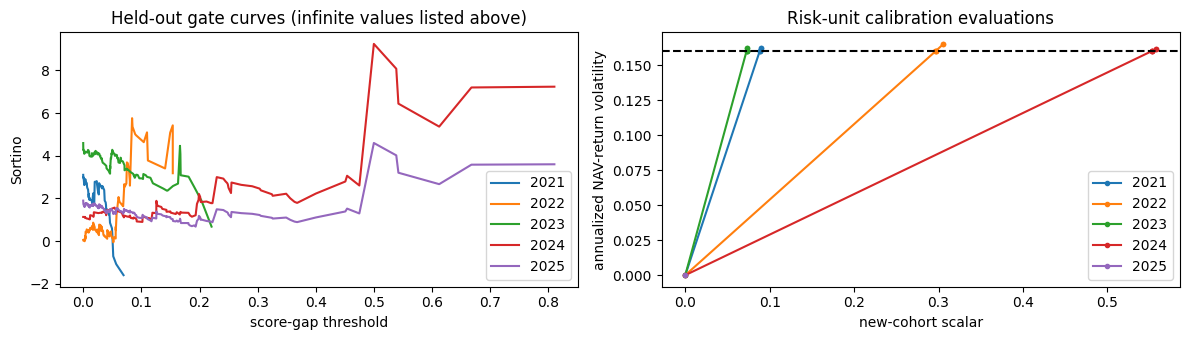

,days,learned_skips,admitted,opened
date,,,,
2021,261,0,261,261
2022,260,0,19,19
2023,260,0,260,260
2024,262,0,7,7
2025,261,0,0,0


,candidate,exitDate,source_risk_usd,allocated_risk_usd,source_units
date,,,,,
2021-01-01,CAC,2021-01-15,1.106853,441026.706859,398451.138581
2021-01-04,DAX,2021-01-15,1.107964,441011.994108,398038.034170
2021-01-05,IBEX,2021-01-15,1.110703,440972.743368,397021.452454
2021-01-06,AS51,2021-01-15,0.656859,442284.884695,673333.143665
2021-01-07,CAC,2021-01-15,1.111192,439820.515267,395809.690761


,nav_before,pnl,nav,returns,entry_risk_usd,active_cohorts_after_close
date,,,,,,
2021-01-01,5.000000e+06,-166.801129,4.999833e+06,-0.000033,441026.706859,1
2021-01-04,4.999833e+06,-444.992782,4.999388e+06,-0.000089,441011.994108,2
2021-01-05,4.999388e+06,14875.984913,5.014264e+06,0.002976,440972.743368,3
2021-01-06,5.014264e+06,-27939.004480,4.986325e+06,-0.005572,442284.884695,4
2021-01-07,4.986325e+06,-9003.462286,4.977322e+06,-0.001806,439820.515267,5
2021-01-08,4.977322e+06,52939.313111,5.030261e+06,0.010636,439026.361803,6
2021-01-11,5.030261e+06,-51538.975211,4.978722e+06,-0.010246,443695.891988,7
2021-01-12,4.978722e+06,8204.468080,4.986927e+06,0.001648,439149.879085,8
2021-01-13,4.986927e+06,71650.838899,5.058577e+06,0.014368,439873.556993,9


,annual_return,annual_vol,sharpe,arithmetic_sharpe,sortino,max_drawdown
2021,0.189630,0.197929,0.958066,0.976543,1.332282,0.115784
2022,0.109144,0.159857,0.682762,0.727561,1.034672,0.090089
2023,0.417846,0.149932,2.786915,2.405403,3.901476,0.090585
2024,0.163823,0.074843,2.188892,2.064718,4.297769,0.029598
2025,0.000000,0.000000,NaN,NaN,NaN,0.000000
2021–2025,0.168247,0.136167,1.235593,1.210517,1.788189,0.115784


,nav_before,pnl,nav,returns,entry_risk_usd,active_cohorts_after_close
settlement_tail,,,,,,
2026-01-01,1.117984e+07,0.0,1.117984e+07,0.0,0.0,0
2026-01-02,1.117984e+07,0.0,1.117984e+07,0.0,0.0,0
2026-01-05,1.117984e+07,0.0,1.117984e+07,0.0,0.0,0
2026-01-06,1.117984e+07,0.0,1.117984e+07,0.0,0.0,0
2026-01-07,1.117984e+07,0.0,1.117984e+07,0.0,0.0,0
2026-01-08,1.117984e+07,0.0,1.117984e+07,0.0,0.0,0
2026-01-09,1.117984e+07,0.0,1.117984e+07,0.0,0.0,0
2026-01-12,1.117984e+07,0.0,1.117984e+07,0.0,0.0,0
2026-01-13,1.117984e+07,0.0,1.117984e+07,0.0,0.0,0


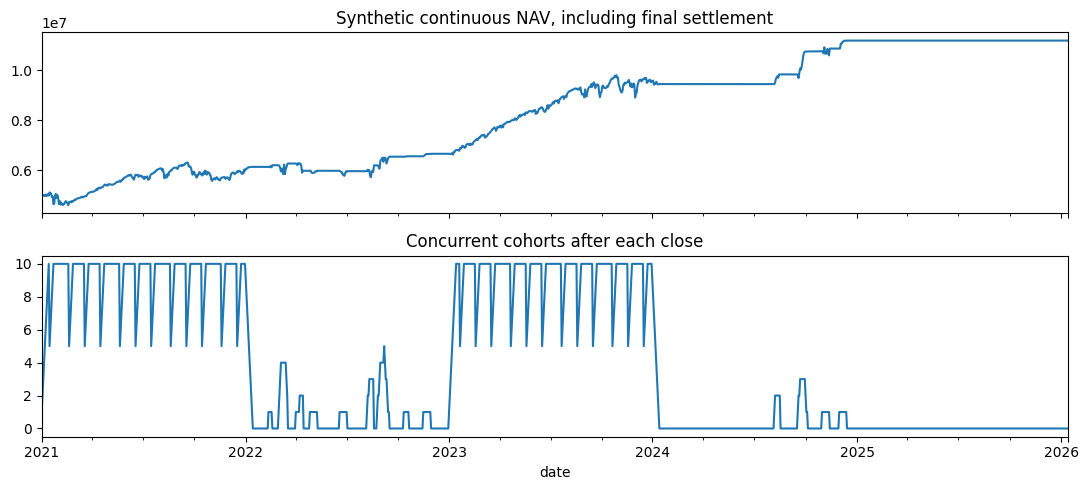

In [15]:
display(pd.DataFrame({year: fitted['audit'].reason.value_counts() for year, fitted in fits.items()}).fillna(0).astype(int))
display(pd.DataFrame({year: fitted['study'].best_params for year, fitted in fits.items()}).T)
last = fits[2025]
gain = pd.Series(last['model'].feature_importance('gain'), index=last['features'], name='gain')
display(last['audit'].loc[last['features']].join(catalog[['scope', 'group', 'definition']]).join(gain))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for year, fitted in fits.items():
    curve = fitted['gate_curve']
    finite = curve.sortino.replace([np.inf, -np.inf], np.nan)
    axes[0].plot(curve.threshold, finite, label=str(year))
    axes[1].plot(fitted['size_curve'].scalar, fitted['size_curve'].annual_vol, '.-', label=str(year))
axes[0].set(title='Held-out gate curves (infinite values listed above)', xlabel='score-gap threshold', ylabel='Sortino')
axes[1].axhline(TARGET_VOL, color='black', linestyle='--')
axes[1].set(title='Risk-unit calibration evaluations', xlabel='new-cohort scalar', ylabel='annualized NAV-return volatility')
axes[0].legend(); axes[1].legend(); plt.tight_layout(); plt.show()

opened = ledger.entry_risk_usd.gt(0)
active = pd.Series(0, index=ledger_calendar)
allocations = decision[['candidate', 'exitDate', 'entry_risk_usd']].rename(columns={'entry_risk_usd': 'source_risk_usd'})
allocations['allocated_risk_usd'] = ledger.entry_risk_usd.reindex(allocations.index)
allocations['source_units'] = np.where(allocations.allocated_risk_usd.gt(0),
    allocations.allocated_risk_usd/allocations.source_risk_usd, 0.)
for date, trade in allocations.loc[allocations.source_units.gt(0)].iterrows():
    active.loc[(active.index >= date) & (active.index < trade.exitDate)] += 1
ledger['active_cohorts_after_close'] = active
decision['admitted'] = decision.candidate.ne('SKIP') & decision.gap.ge(decision.threshold)
display(decision.groupby(decision.index.year).agg(
    days=('candidate', 'size'), learned_skips=('candidate', lambda s: s.eq('SKIP').sum()),
    admitted=('admitted', 'sum')).assign(opened=opened.groupby(opened.index.year).sum()))
display(allocations.loc[allocations.source_units.gt(0)].head())
first_trade_date = ledger.index[opened][0] if opened.any() else ledger.index[0]
display(ledger.loc[first_trade_date:first_trade_date+pd.offsets.BDay(HOLD)])

evaluation = ledger.loc[ledger.index < pd.Timestamp('2026-01-01')]
metrics = pd.DataFrame({str(year): performance(group.returns)
    for year, group in evaluation.groupby(evaluation.index.year)}).T
metrics.loc['2021–2025'] = performance(evaluation.returns)
display(metrics)
display(ledger.loc[ledger.index >= pd.Timestamp('2026-01-01')].rename_axis('settlement_tail'))
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ledger.nav.plot(ax=axes[0], title=f'{DATA_SOURCE.capitalize()} continuous NAV, including final settlement')
ledger.active_cohorts_after_close.plot(ax=axes[1], title='Concurrent cohorts after each close')
plt.tight_layout(); plt.show()

## 11. Checks shared by synthetic and real inputs

The synthetic pricer/roll examples were checked inside C. Here we verify the
selected input tables, shared features, labels, completed-path reconciliation,
all 250 trials and portfolio accounting. No fixed synthetic ticker or toy
expiry schedule is referenced.

The focused timing regression is runnable through DEV:
`./cmd/run DEV scripts/research/check_harvesting_v2_timing.py`.
It perturbs day-t-and-later observations and requires the complete feature
matrix through t to stay unchanged, then checks sensitivity to t−1 inputs.


In [16]:
def check_notebook():
    assert all(pd.api.types.is_integer_dtype(frame.secId.dtype)
               for frame in [idx_ref, flows, features_long, panel])
    assert panel.index.is_unique and panel.index.is_monotonic_increasing
    assert panel.loc[real, 'secId'].notna().all() and panel.loc[~real, 'secId'].isna().all()
    assert panel.groupby(level='date').size().le(len(TICKERS)+1).all()
    assert panel.loc[~real, 'z'].eq(0).all()
    assert not {'ticker', 'candidate', 'z'}.intersection(X.columns)
    assert not any(name.startswith('history_') for name in X)
    assert X.loc[~real, 'returns_on_margin'].eq(0).all()
    rank_columns = [output+'_wd_rank' for output in rank_sources]
    ordinary_ps = catalog.index[catalog.scope.eq('PS')].difference(['returns_on_margin', *rank_columns])
    assert X.loc[~real, ordinary_ps].isna().all().all()
    for column in catalog.index[catalog.scope.eq('CS')]:
        assert X[column].groupby(level='date').nunique(dropna=False).eq(1).all()
    for name in history:
        expected = history[name].reindex(join_keys).to_numpy()
        np.testing.assert_allclose(X.loc[real, name], expected[real], equal_nan=True)
    for output, source in rank_sources.items():
        expected = X.loc[real, source].groupby(level='date').rank(ascending=False, method='average')
        pd.testing.assert_series_equal(X.loc[real, output+'_wd_rank'], expected, check_names=False)
        assert X.loc[~real, output+'_wd_rank'].eq(len(TICKERS)+.5).all()
    assert completed.label_available.notna().all()
    np.testing.assert_allclose(completed.rom, completed.gross_usd/completed.premium_usd)
    assert not np.isinf(X.to_numpy()).any()
    observed = vix_alignment.scheduled_close.notna()
    assert vix_alignment.loc[observed, 'scheduled_close'].le(
        vix_alignment.loc[observed, 'information_cutoff']).all()
    for column in vix_features:
        assert X[column].groupby(level='date').nunique(dropna=False).eq(1).all()
        pd.testing.assert_series_equal(X[column].xs('SKIP', level='candidate'),
            vix_at_entry[column].rename_axis('date'), check_names=False, check_freq=False)
    for greek in ['delta', 'gamma', 'theta', 'vega']:
        np.testing.assert_allclose(X.loc[real, 'position_'+greek],
            STRUCTURE_WEIGHT*prior_position.loc[real, greek]
            /(prior_position.loc[real, 'qty']*prior_position.loc[real, 'contractSize']), equal_nan=True)
    assert not {'position_delta_spot', 'delta_spot_x_VIX', 'position_gamma_spot2',
                'position_theta_day', 'position_vega_iv', 'vega_iv_x_VIX_5d_pct_change',
                'vega_iv_x_VVIX_1y_percentile'}.intersection(X)
    known_observation = aligned_clock.observation_date.notna()
    assert aligned_clock.loc[known_observation, 'observation_date'].lt(
        row_dates[known_observation]).all()
    for name, (left, right) in products.items():
        multiplier = X[right] if right else X.vol_ctc__vol_ctc_21**2/ANN
        np.testing.assert_allclose(X.loc[real, name], X.loc[real, left]*multiplier.loc[real], equal_nan=True)
        assert X.loc[~real, name].isna().all()
    assert daily_raw.groupby(PATH_KEY).qty.nunique().eq(1).all()
    assert flows.loc[flows.tradeOpen, 'pnlOpt'].eq(0).all()
    np.testing.assert_allclose(flows.gross_per_risk, -flows.pnlOpt*flows.fx_price/flows.entry_risk_usd)
    np.testing.assert_allclose(flows.net_per_risk, flows.gross_per_risk-flows.cost_per_risk)
    assert flows.sourceQty.eq(flows.qty).all()
    # /trd checks completed identities only; it never removes an open candidate.
    terminal = terminal_raw.set_index(PATH_KEY).pnlOpt.sort_index()
    completed_keys = labels.index[complete]
    assert terminal.index.isin(completed_keys).all() and completed_keys.isin(terminal.index).all()
    summed = daily_raw.groupby(PATH_KEY).pnlOpt.sum().reindex(terminal.index)
    np.testing.assert_allclose(summed, terminal)
    assert labels.loc[~complete, ['z', 'label_available']].isna().all().all()
    for year, fitted in fits.items():
        roles = fitted['roles']
        assert len(fitted['study'].trials) == PAPER_TRIALS
        assert fitted['params']['objective'] == 'lambdarank'
        assert fitted['params']['label_gain'] == GAIN.tolist()
        assert (panel.loc[fitted['refit_fit'], 'label_available'] < roles['stop_start']).all()
        assert (panel.loc[fitted['selection_mask'], 'label_available'] < roles['gate_start']).all()
        assert fitted['gate_top'].label_available.lt(roles['prediction_start']).all()
        assert fitted['gate_top'].index.min() >= roles['gate_start']
        assert set(fitted['gate_curve'].threshold) == set(np.r_[0., fitted['gate_sample'].gap])
        if fitted['size_status'] == 'target solved':
            nearest = (fitted['size_curve'].scalar-fitted['scalar']).abs().idxmin()
            assert np.isclose(fitted['size_curve'].loc[nearest, 'annual_vol'], TARGET_VOL)
    archived = pd.concat([top for top, _ in gate_archive]).sort_index()
    pd.testing.assert_frame_equal(fits[2025]['gate_sample'], archived)
    # Independent one-cohort example: second-day SKIP still realizes earlier P&L.
    toy_calendar = pd.bdate_range('2025-01-01', periods=3)
    toy = csr_matrix(np.array([[-.01, 0., 0.], [.02, 0., 0.], [-.03, 0., 0.]]))
    toy_ledger = simulate(toy, toy_calendar, np.array([True, False, False]), .1, initial_nav=100.)
    np.testing.assert_allclose(toy_ledger.pnl, [-.1, .2, -.3])
    assert toy_ledger.entry_risk_usd.iloc[1] == 0 and toy_ledger.pnl.iloc[1] != 0
    # All cohort cash flows, including the January tail, reconcile with the daily ledger.
    np.testing.assert_allclose(ledger.pnl.to_numpy(), matrix @ ledger.entry_risk_usd.to_numpy())
    assert np.isclose(ledger.nav.iloc[-1], NAV0+ledger.pnl.sum())
    assert ledger.loc[ledger.index.year == 2026, 'entry_risk_usd'].eq(0).all()
    assert ledger.active_cohorts_after_close.iloc[-1] == 0

    print(f'PASS ({DATA_SOURCE}): source boundary, features, label timing, 250 trials, calibration and ledger.')


check_notebook()
print(f'Executed end to end in {time.perf_counter()-started:.1f} seconds.')

PASS (synthetic): source boundary, features, label timing, 250 trials, calibration and ledger.
Executed end to end in 131.3 seconds.


## 12. Switching to your real history

Return to **B, `load_real_inputs()`**. That is the only data-specific cell to
edit. It already shows the documented Qbit reads for `idxRef`, raw `/date`,
raw `/trd` and the feature families. Connect the remaining named readers there,
set **A to `real`**, restart the kernel and Run All. The D inventory is your
checkpoint: inspect its rows, sample source quantities, dates and clock values
before fitting. If a table is malformed, D names the failing input.

Apollo3 DEV executes the saved synthetic example. Direct Qbit reads require the
Qbit environment named in [the feature guide](../../docs/qbit/features.md) and
[the UPNL guide](../../docs/qbit/upnl.md); alternatively read prepared exports
into exactly these DataFrames in B. This workspace has not read your private
Qbit binaries, FX source or VIX/VVIX price store.

Use **raw long-source unit-rtvega P&L**. A `qty_one` table, signed portfolio
panel or already-USD `pnl_usd` table has a different contract and must not be
fed through the same conversion again. `/date` openings define candidate
availability; `/trd` only reconciles completed paths. The real source must
already carry the intended put, fixed expiry and earlier-of-expiry/ten-day exit.

The prior-US-session rule is shared. Supply actual VIX/VVIX point timestamps or
correctly interpreted bar-end stamps, a matching close-sample calendar, and
publication-aware input snapshots. The shared sampler requires an observation
at the scheduled close; a missing close stays missing. Do not label a last
arbitrary quote of an incomplete day as the close. Later revisions are not
historically available observations.

The clock contract is part of the boundary, not a request to change feature or
model code. For EOD t execution, `feature_cutoff_at` is the preceding research
EOD. Persisted features, prior candidate Greeks and completed-trade marks
must all be available by that cutoff. Day-t quotes belong to execution and P&L.
Exact `observation_date` joins preserve
each index's holidays and source gaps. Completed-trade windows and NAV metrics
use the explicit daily research calendar, including zero-P&L dates.

P&L remains **unhedged** (`pnlOpt`, with the short sign applied downstream).
Costs supplied here are entry costs. Funding, hedge costs, unprovided closing
costs and cash interest are excluded. Risk-unit sizing is the approved research
adaptation; real margin and contract granularity are separate execution inputs.